In [2]:
import scipy.io as scio
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import cv2
import random
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" 

'''生成annotations涡旋标注数据集'''


def latlon_to_pixel(lat, lon, clip_to_bounds=True):
    # lon_min= -150
    # lon_max= -148
    # lat_min= 0
    # lat_max= 2
    lon_min = -71.0
    lon_max = -69.0
    lat_min = 37.0
    lat_max = 39.0
    deg_per_pixel = 2.0 / 25
    grid_height, grid_width = (25,25)
    
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    
    pixel_x = (lon - lon_min) / deg_per_pixel
    pixel_y = (lat_max - lat) / deg_per_pixel  # y轴从上往下
    
    if clip_to_bounds:
        pixel_x = np.clip(pixel_x, 0, grid_width - 1)
        pixel_y = np.clip(pixel_y, 0, grid_height - 1)
    
    return pixel_x, pixel_y

def pixel_to_latlon(pixel_x, pixel_y):
    # lon_min = -150.0
    # lon_max = -148.0
    # lat_min = 0.0
    # lat_max = 2.0
    lon_min = -71.0
    lon_max = -69.0
    lat_min = 37.0
    lat_max = 39.0
    lon = lon_min + (pixel_x / 25) * (lon_max - lon_min)
    lat = lat_max - (pixel_y / 25) * (lat_max - lat_min)  # y轴从上往下
    
    return lat, lon

def generate_eddy_annotations_from_trajectory(eddy_data):
    ds = eddy_data
    lat = ds['labeled_eddy_lat'][:].reshape(-1,)
    lon = ds['labeled_eddy_lon'][:].reshape(-1,)
    radius_deg = ds['labeled_eddy_degrees_radius'][:].reshape(-1,)
    time = ds['labeled_time_str'][:]
    amplitude = ds['labeled_eddy_amplitude'][:].reshape(-1,)
    annotations = []
    deg_per_pixel = 2.0 / 25
    
    for i in range(len(time)):

        
        img_x, img_y = latlon_to_pixel(lat[i], lon[i])
        pixel_radius = radius_deg[i] / deg_per_pixel

        # 计算原始的边界框（像素坐标）
        left_px = img_x - pixel_radius
        right_px = img_x + pixel_radius
        top_px = img_y - pixel_radius  # 注意：y轴从上往下，top对应较小的y值
        bottom_px = img_y + pixel_radius

        # 记录哪些边界需要调整
        adjusted_left = left_px
        adjusted_right = right_px
        adjusted_top = top_px
        adjusted_bottom = bottom_px

        # 检查并调整超出边界的部分
        if left_px < 0:
            # 左边界超出，向右平移
            adjusted_left = 0
            
        if right_px > 24:
            # 右边界超出，向左平移
            adjusted_right = 25

        if top_px < 0:
            # 上边界超出，向下平移
            adjusted_top = 0

        if bottom_px > 24:
            # 下边界超出，向上平移
            adjusted_bottom = 25

        # 计算调整后的中心点和尺寸
        adjusted_center_x = (adjusted_left + adjusted_right) / 2
        adjusted_center_y = (adjusted_top + adjusted_bottom) / 2
        adjusted_width = adjusted_right - adjusted_left
        adjusted_height = adjusted_bottom - adjusted_top

        # 转换为归一化坐标（YOLO格式）
        cx_norm = adjusted_center_x / 25
        cy_norm = adjusted_center_y / 25
        w_norm = adjusted_width / 25
        h_norm = adjusted_height / 25
        bbox = [cx_norm, cy_norm, w_norm, h_norm]
        

        annotations.append({
            'time': time[i],
            'original_lat': float(lat[i]),
            'original_lon': float(lon[i]),
            'original_radius_deg': float(radius_deg[i]),
            'pixel_center': (float(img_x), float(img_y)),
            'pixel_radius': float(pixel_radius),
            'bbox': bbox,
            'class_id': 0,
            'amplitude':amplitude[i]
        })
    
    # print(f"Generated {len(annotations)} valid annotations")
    return annotations


def yolo_bbox_to_latlon_extent(bbox):
    """
    将YOLO边界框转换为经纬度范围
    
    参数:
    ----------
    bbox : list [cx_norm, cy_norm, w_norm, h_norm]
    
    返回:
    --------
    extent : tuple (lon_min, lon_max, lat_min, lat_max)
    """
    cx_norm, cy_norm, w_norm, h_norm = bbox
    
    # 图像覆盖范围
    lon_min_img, lon_max_img = -71,-69#-150, -148
    lat_min_img, lat_max_img = 37,39#0, 2#
    
    # 计算中心点经纬度
    center_lon = lon_min_img + cx_norm * (lon_max_img - lon_min_img)
    # 注意：cy_norm是从上往下的，纬度是从下往上的
    center_lat = lat_max_img - cy_norm * (lat_max_img - lat_min_img)
    
    # 计算宽度和高度（度数）
    width_deg = w_norm * (lon_max_img - lon_min_img)
    height_deg = h_norm * (lat_max_img - lat_min_img)
    
    # 计算边界
    lon_left = center_lon - width_deg/2
    lon_right = center_lon + width_deg/2
    lat_bottom = center_lat - height_deg/2
    lat_top = center_lat + height_deg/2
    
    # 确保在图像范围内
    lon_left = max(lon_min_img, lon_left)
    lon_right = min(lon_max_img, lon_right)
    lat_bottom = max(lat_min_img, lat_bottom)
    lat_top = min(lat_max_img, lat_top)
    
    return lon_left, lon_right, lat_bottom, lat_top

def visualize_annotation(idx,ocean_eddy,annotations):
    # 可视化
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 获取经纬度网格和数据
    lat_grid = ocean_eddy['labeled_latitude'][0]  # 形状应该是(25, 25)
    lon_grid = ocean_eddy['labeled_longitude'][0]  # 形状应该是(25, 25)
    u0_data = ocean_eddy['labeled_uo'][idx,0,...]  # 形状(25, 25)
    v0_data = ocean_eddy['labeled_vo'][idx,0,...]  # 形状(25, 25)



    # 第一幅图：u0场（使用正确的网格）
    pcm0 = axes[0].pcolormesh(lon_grid, lat_grid, u0_data, cmap='coolwarm', shading='auto')
    axes[0].set_title('u0 Field')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    # axes[0].set_xlim(-150, -148)
    # axes[0].set_ylim(0, 2)
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    fig.colorbar(pcm0, ax=axes[0], label='v0 (m/s)')

    # 第二幅图：v0场 + 边界框
    pcm1 = axes[1].pcolormesh(lon_grid, lat_grid, v0_data, cmap='coolwarm', shading='auto')
    axes[1].set_title('v0 Field with BBox')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    # axes[1].set_xlim(-150, -148)
    # axes[1].set_ylim(0, 2)
    axes[1].set_aspect('equal')
    axes[1].grid(True, alpha=0.3)
    fig.colorbar(pcm1, ax=axes[1], label='v0 (m/s)')

    # 第三幅图：流场图 + 边界框
    dx = 111320 * 0.083 * np.cos(np.deg2rad(lat_grid))  # 经度方向
    dy = 111320 * 0.083  # 纬度方向
    dv_dx = np.gradient(v0_data, axis=1) / dx[:, np.newaxis]
    du_dy = np.gradient(u0_data, axis=0) / dy
    vorticity = dv_dx - du_dy
    vort_magnitude = np.abs(vorticity)
    axes[2].contourf(lon_grid, lat_grid, vort_magnitude, levels=30, alpha=0.6, cmap='YlOrRd')
    axes[2].set_title('Flow Field with BBox')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    # axes[2].set_xlim(-150, -148)
    # axes[2].set_ylim(0, 2)
    axes[2].set_aspect('equal')
    axes[2].grid(True, alpha=0.3)

    if idx < len(annotations):
        bbox = annotations[idx]['bbox']
        center_lat = annotations[idx]['original_lat']
        center_lon = annotations[idx]['original_lon']
        
        # 获取边界框的经纬度范围
        lon_left, lon_right, lat_bottom, lat_top = yolo_bbox_to_latlon_extent(bbox)
        
        print(f"\n涡旋 {idx} 信息:")
        print(f"  中心点: ({center_lat:.3f}°, {center_lon:.3f}°)")
        print(f"  边界框: lon=[{lon_left:.3f}, {lon_right:.3f}], lat=[{lat_bottom:.3f}, {lat_top:.3f}]")
        print(f"  边界框大小: {lon_right-lon_left:.3f}° × {lat_top-lat_bottom:.3f}°")
        
        # 在三个子图上绘制相同的边界框
        from matplotlib.patches import Rectangle
        
        for ax in axes:
            # 绘制边界框
            rect = Rectangle(
                (lon_left, lat_bottom),
                lon_right - lon_left,
                lat_top - lat_bottom,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            
            # 绘制涡旋中心
            ax.plot(center_lon, center_lat, 'ro', markersize=8, label='Eddy center')
        
        # 只在axes[2]上绘制流场
        skip = 2
        quiv = axes[2].quiver(lon_grid[::skip], lat_grid[::skip],
                            u0_data[::skip,::skip],
                            v0_data[::skip,::skip],
                            scale=40, width=0.002, color='blue')
        
        # 添加文本信息到axes[1]
        info = (f"Center: ({center_lat:.3f}°, {center_lon:.3f}°)\n"
                f"Radius: {annotations[idx]['original_radius_deg']:.3f}°\n"
                f"BBox: [{lon_left:.3f}, {lon_right:.3f}]×"
                f"[{lat_bottom:.3f}, {lat_top:.3f}]")
        
        axes[1].text(0.02, 0.98, info, transform=axes[1].transAxes,
                    verticalalignment='top', fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # 验证边界框是否包含涡旋中心
        contains_center = (lon_left <= center_lon <= lon_right and 
                        lat_bottom <= center_lat <= lat_top)
        print(f"  边界框是否包含中心点: {contains_center}")
        print(f" {ocean_eddy['labeled_time_str'][idx]}")
        if not contains_center:
            print("  警告: 边界框不包含涡旋中心!")
            print(f"  中心点偏移: lon差={center_lon-(lon_left+lon_right)/2:.3f}°, "
                f"lat差={center_lat-(lat_bottom+lat_top)/2:.3f}°")

    # 添加图例
    for ax in axes[:2]:
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
def visualize_flow(idx,ocean_eddy,if_plot_label):
    # 可视化
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 获取经纬度网格和数据
    if if_plot_label:
        lat_grid = ocean_eddy['labeled_latitude'][0]  # 形状应该是(25, 25)
        lon_grid = ocean_eddy['labeled_longitude'][0]  # 形状应该是(25, 25)
        u0_data = ocean_eddy['labeled_uo'][idx,0,...]  # 形状(25, 25)
        v0_data = ocean_eddy['labeled_vo'][idx,0,...]  # 形状(25, 25)
        print(f" {ocean_eddy['labeled_time_str'][idx]}")
    else:
        lat_grid = ocean_eddy['unlabeled_latitude'][0]  # 形状应该是(25, 25)
        lon_grid = ocean_eddy['unlabeled_longitude'][0]  # 形状应该是(25, 25)
        u0_data = ocean_eddy['unlabeled_uo'][idx,0,...]  # 形状(25, 25)
        v0_data = ocean_eddy['unlabeled_vo'][idx,0,...]  # 形状(25, 25)        
        print(f" {ocean_eddy['unlabeled_time_str'][idx]}")

    

    # 第一幅图：u0场（使用正确的网格）
    pcm0 = axes[0].pcolormesh(lon_grid, lat_grid, u0_data, cmap='coolwarm', shading='auto')
    axes[0].set_title('u0 Field')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    # axes[0].set_xlim(-150, -148)
    # axes[0].set_ylim(0, 2)
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    fig.colorbar(pcm0, ax=axes[0], label='v0 (m/s)')

    # 第二幅图：v0场
    pcm1 = axes[1].pcolormesh(lon_grid, lat_grid, v0_data, cmap='coolwarm', shading='auto')
    axes[1].set_title('v0 Field with BBox')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    # axes[1].set_xlim(-150, -148)
    # axes[1].set_ylim(0, 2)
    axes[1].set_aspect('equal')
    axes[1].grid(True, alpha=0.3)
    fig.colorbar(pcm1, ax=axes[1], label='v0 (m/s)')

    # 第三幅图：流场图
    axes[2].set_title('Flow Field')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    # axes[2].set_xlim(-150, -148)
    # axes[2].set_ylim(0, 2)
    axes[2].set_aspect('equal')
    axes[2].grid(True, alpha=0.3)
    skip = 2
    quiv = axes[2].streamline(lon_grid[::skip], lat_grid[::skip],
                            u0_data[::skip,::skip],
                            v0_data[::skip,::skip],
                            scale=40, width=0.002, color='blue')
    plt.tight_layout()
    plt.show()

from model_evaluation import *
def evaluate_model(model, test_data, test_labels):
    """
    评估模型性能
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    
    with torch.no_grad():
        test_data = torch.tensor(test_data).to(device)
        output, _ ,_= model(test_data)
        probabilities = F.softmax(output, dim=1)
        probs = probabilities[:, 1].cpu().numpy()  # 正类概率
        # predictions = output.argmax(dim=1).cpu().numpy()
        
    
    # 计算指标
    
    auc, csi = calculate_metrics_original(decision_values=probs.reshape(-1,1), truth=test_labels.reshape(-1,1), hazard_id = 1)
    # accuracy = accuracy_score(all_labels, all_predictions)
    # precision = precision_score(all_labels, all_predictions, zero_division=0)
    # recall = recall_score(all_labels, all_predictions, zero_division=0)
    # f1 = f1_score(all_labels, all_predictions, zero_division=0)
    # auc = roc_auc_score(all_labels, all_probs)
    
    # # CSI (Critical Success Index)
    # TP = np.sum((np.array(all_predictions) == 1) & (np.array(all_labels) == 1))
    # FP = np.sum((np.array(all_predictions) == 1) & (np.array(all_labels) == 0))
    # FN = np.sum((np.array(all_predictions) == 0) & (np.array(all_labels) == 1))
    # csi = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    
    metrics = {
        # 'accuracy': accuracy,
        # 'precision': precision,
        # 'recall': recall,
        # 'f1_score': f1,
        'auc': auc,
        'csi': csi,
        # 'predictions': np.array(all_predictions),
        # 'probabilities': np.array(all_probs),
        # 'labels': np.array(all_labels)
    }
    
    # print(f"模型评估结果:")
    # print(f"Accuracy: {accuracy:.4f}")
    # print(f"Precision: {precision:.4f}")
    # print(f"Recall: {recall:.4f}")
    # print(f"F1-Score: {f1:.4f}")
    # print(f"AUC: {auc:.4f}")
    # print(f"CSI: {csi:.4f}")
    
    return metrics

def set_all_seeds(seed=42):
    """
    设置所有可能的随机种子以确保完全可复现
    """
    # Python内置随机
    random.seed(seed)
    
    # NumPy随机
    np.random.seed(seed)
    
    # PyTorch CPU随机
    torch.manual_seed(seed)
    
    # PyTorch GPU随机
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # 多GPU
    
    # cuDNN设置
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    # 操作系统环境变量（某些库会用到）
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # print(f"✅ 所有随机种子已设置为: {seed}")
    # print(f"   PyTorch确定性模式: {torch.backends.cudnn.deterministic}")
    # print(f"   PyTorch基准模式: {torch.backends.cudnn.benchmark}")
class EddyDataset(torch.utils.data.Dataset):
    """海洋涡旋数据集"""
    
    def __init__(self, data, labels, annotations=None, transform=None):
        """
        data: [N, 3, 25, 25] 的numpy数组
        labels: [N,] 的numpy数组 (0或1)
        """
        self.data = torch.FloatTensor(data)
        self.labels = torch.LongTensor(labels)
        self.annotations = annotations
        if self.annotations is not None:
            self.full_annotations =torch.FloatTensor(self.annotations)
        self.transform = transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.labels[idx]
        if self.transform:
            x = self.transform(x)
        if self.annotations is None:
            return x, y
        else:
            ann = self.full_annotations[idx]  # 涡旋数据有标注，非涡旋为None
            return x, y, ann
from matplotlib.patches import Circle
from matplotlib.colors import LinearSegmentedColormap
purple_cmap = LinearSegmentedColormap.from_list('white_to_purple', ['#FFFFFF', "#B29DC5"], N=256)
def visualize_attention_with_stream(model, test_sample, u_data, v_data, background='black', 
                                   has_eddy=False, eddy_info=None, alpha_annotation = None):
    """
    可视化注意力图和伪彩色流线图
    
    参数:
    ----------
    model: 训练好的模型
    test_sample: 测试样本 [3, 25, 25]
    u_data, v_data: 流场数据 [25, 25]
    background: 背景颜色 'black' 或 'white'
    has_eddy: 是否有涡旋标注
    eddy_info: 涡旋信息字典，包含中心位置、半径等
    """
    model.eval()
    
    # 自动获取模型所在的设备
    device = next(model.parameters()).device
    
    # 准备输入
    if isinstance(test_sample, np.ndarray):
        test_sample_tensor = torch.FloatTensor(test_sample).unsqueeze(0).to(device)
    elif isinstance(test_sample, torch.Tensor):
        test_sample_tensor = test_sample.unsqueeze(0).to(device)
    
    # 前向传播获取注意力图
    with torch.no_grad():
        # output, attention_map,_ = model(test_sample_tensor)
        output, attention_map, decoded_feature,guidance_map, physics_guidance, annotation_guidance = \
                    model(test_sample_tensor, (eddy_info,), alpha_annotation)
        
        probabilities = F.softmax(output, dim=1)
        pred_class = output.argmax(dim=1).item()
        pred_prob = probabilities[0, pred_class].item()
    
    # 获取注意力图和数据
    attention_map_np = attention_map.squeeze().cpu().numpy()  # [4, 4]
    sample_data = test_sample_tensor.squeeze().cpu().numpy()  # [3, 25, 25]
    guidance_map_np = guidance_map.squeeze().cpu().numpy() 
    physics_guidance_np = physics_guidance.squeeze().cpu().numpy()
    annotation_guidance_np = annotation_guidance.squeeze().cpu().numpy()
    guidance_map_resized = cv2.resize(guidance_map_np, (25, 25), interpolation=cv2.INTER_CUBIC) 
    physics_guidance_resized = cv2.resize(physics_guidance_np, (25, 25), interpolation=cv2.INTER_CUBIC)
    annotation_guidance_resized = cv2.resize(annotation_guidance_np, (25, 25), interpolation=cv2.INTER_CUBIC)
    # 将4×4的注意力图上采样到25×25以便可视化
    attention_map_resized = cv2.resize(attention_map_np, (25, 25), interpolation=cv2.INTER_CUBIC)
    
    # 获取zos数据并创建伪彩色图
    zos_data = sample_data[2]  # [25, 25]
    # 归一化到0-1
    zos_normalized = (zos_data - zos_data.min()) / (zos_data.max() - zos_data.min() + 1e-8)
    # 应用viridis colormap
    cmap = plt.cm.viridis
    zos_pseudocolor = (cmap(zos_normalized)[:, :, :3] * 255).astype(np.uint8)
    
    # 创建坐标网格（25×25网格）
    x = np.arange(25)
    y = np.arange(25)
    X, Y = np.meshgrid(x, y)
    
    # 创建图形
    fig, axes = plt.subplots(2, 3, figsize=(14, 10))
    
    # 图1: 伪彩色zos + 流线
    axes[0,0].imshow(zos_pseudocolor, origin='lower')
    
    # 绘制流线
    stream = axes[0,0].streamplot(X, Y, u_data, v_data, 
                               color='white' if background == 'black' else 'black',
                               linewidth=1.5,
                               arrowsize=0.5,
                               density=2.0,
                               arrowstyle='->')
    
    
    # 如果有涡旋标注，标注真实涡旋中心
    if has_eddy and eddy_info is not None:
        from matplotlib.patches import Rectangle
        #bbox : list [cx_norm, cy_norm, w_norm, h_norm]
        # cx_norm, cy_norm, w_norm, h_norm = eddy_info
        # rect = Rectangle(
        #         ((cx_norm-w_norm/2)*25, (cy_norm-h_norm/2)*25),
        #         w_norm*25,
        #         h_norm*25,
        #         linewidth=2, edgecolor='red', facecolor='none'
        #     )
        # axes[0,0].add_patch(rect)
        # # 绘制涡旋中心
        # axes[0,0].plot(cx_norm*25, cy_norm*25, 'ro', markersize=8, label='Eddy center')
        _,_,_,_,c_lat, c_lon, r_pixel,_ = eddy_info
        lon_min = -71.0
        lat_max = 39.0
        deg_per_pixel = 2.0 / 25
        cx = (c_lon - lon_min) / deg_per_pixel
        cy = (lat_max - c_lat) / deg_per_pixel  # y轴从上往下
        r = r_pixel #r是在25*25的网格上定义的     
        circle = Circle(
                    xy=(cx,cy),      # 圆心坐标 (x, y)
                    radius=r,        # 半径
                    edgecolor='red',    # 边框颜色
                    facecolor='none', # 填充颜色
                    linewidth=3,        # 边框宽度
                    linestyle='--',     # 边框样式
                )
        axes[0,0].add_patch(circle)
    axes[0,0].set_title(f'ZOS Pseudocolor + Streamlines')
    axes[0,0].set_xlabel('X (grid points)')
    axes[0,0].set_ylabel('Y (grid points)')
    # axes[0,0].set_xlim(0, 24)
    # axes[0,0].set_ylim(0, 24)
    # axes[0,0].grid(True, alpha=0.3, linestyle='--')
    axes[0,0].set_xticks([0,25/3,2*25/3])
    axes[0,0].set_yticks([0,25/3,2*25/3])
    # 图2: 自注意力图
    im = axes[0,1].imshow(attention_map_np, cmap=purple_cmap, origin='lower', aspect='auto')# interpolation='bilinear',
    
    # 添加等高线显示注意力分布
    # CS = axes[0,1].contour(X, Y, attention_map_resized, 
    #                     levels=5, colors='white', alpha=0.7, linewidths=1)
    # axes[0,1].clabel(CS, inline=True, fontsize=8, fmt='%.2f')
    
    # 标记最大注意力区域
    max_pos = np.unravel_index(attention_map_np.argmax(), attention_map_np.shape)
    axes[0,1].plot(max_pos[1], max_pos[0], 'g*', markersize=15, 
                label=f'Max Attention ({max_pos[1]},{max_pos[0]})')
    

    
    axes[0,1].set_title('Self-Attention Map ')
    axes[0,1].set_xlabel('X (grid points)')
    axes[0,1].set_ylabel('Y (grid points)')
    # axes[0,1].set_xlim(0, 2)
    # axes[0,1].set_ylim(0, 2)
    axes[0,1].legend(loc='upper right', fontsize=8)
    dv_dx = np.gradient(v_data, axis=1) 
    du_dy = np.gradient(u_data, axis=0) 
    vorticity = dv_dx - du_dy
    vort_magnitude = np.abs(vorticity)#
    axes[0,2].contourf(vort_magnitude, levels=30, alpha=0.6, cmap='YlOrRd')
    
    im1 = axes[1,0].imshow(guidance_map_np, cmap=purple_cmap, origin='lower',
                       aspect='auto')#interpolation='bilinear', 
    im2 = axes[1,1].imshow(physics_guidance_np, cmap=purple_cmap, origin='lower', aspect='auto')#interpolation='bilinear',
    im3 = axes[1,2].imshow(annotation_guidance_np, cmap=purple_cmap, origin='lower', aspect='auto')#interpolation='bilinear',
    axes[0,2].set_title('vorticity')
    axes[1,0].set_title('guidance_map')
    axes[1,1].set_title('physics_guidance')
    axes[1,2].set_title('annotation_guidance')
    # 添加颜色条
    plt.colorbar(im1, ax=axes[1,0], label='Attention Weight')
    plt.colorbar(im2, ax=axes[1,1], label='Attention Weight')
    plt.colorbar(im3, ax=axes[1,2], label='Attention Weight')
    plt.tight_layout()
    plt.show()
    
    # 打印注意力统计信息
    print(f"注意力图统计:")
    print(f"  最小值: {attention_map_np.min():.4f}")
    print(f"  最大值: {attention_map_np.max():.4f}")
    print(f"  平均值: {attention_map_np.mean():.4f}")
    print(f"  标准差: {attention_map_np.std():.4f}")
    print(f"  最大注意力位置 (4×4坐标): {np.unravel_index(attention_map_np.argmax(), attention_map_np.shape)}")
    print(f"  最大注意力位置 (25×25坐标): {max_pos}")
    
    return attention_map_np, attention_map_resized, pred_class, pred_prob

class SoftGuidanceGenerator(nn.Module):
    """
    软引导生成器（SGG） 
    结合物理先验（涡度、能量）和标注信息生成引导图
    """
    
    def __init__(self,guidance_size=3):
        super().__init__()
        
        self.guidance_size = guidance_size
        
        # 物理特征计算不需要可训练参数
        self.register_buffer('dummy', torch.zeros(1))

    
    def compute_physics_features(self, u, v, beta=0.5, z=None,percentile = 95):
        """计算物理特征：涡度和Delta"""
        if z == None:
            z = torch.ones_like(u)
        dv_dx = torch.gradient(v, dim=3)[0]  # ∂v/∂x
        dv_dy = torch.gradient(v, dim=2)[0]  # ∂v/∂x
        du_dy = torch.gradient(u, dim=2)[0]  # ∂u/∂y
        du_dx = torch.gradient(u, dim=3)[0]  # ∂u/∂y
        vorticity = torch.abs(dv_dx - du_dy)
        S_xx = du_dx                    # S[0,0]
        S_yy = dv_dy                    # S[1,1]
        S_xy = 0.5 * (du_dy + dv_dx)    # S[0,1] = S[1,0]
        Omega_12 = 0.5 * vorticity     # Ω[0,1]
        Omega_21 = -0.5 * vorticity    # Ω[1,0]
        # 计算Frobenius范数
        # ‖Ω‖² = Ω_12² + Ω_21² = 2*(ω/2)² = ω²/2
        Omega_norm_sq = Omega_12**2 + Omega_21**2
        # ‖S‖² = S_xx² + 2*S_xy² + S_yy²
        S_norm_sq = S_xx**2 + 2 * S_xy**2 + S_yy**2
        # Q值
        Q = 0.5 * (Omega_norm_sq - S_norm_sq)
        det_gradV = du_dx * dv_dy - du_dy * dv_dx
        Delta = (Q/3)**3 + (det_gradV/2)**2
        # physics_guidance = 0.5 * vorticity_norm + 0.5 * Deltay_norm
        
        
        # 下采样到引导图尺寸
        kernel_size = u.shape[2] // self.guidance_size
        vorticity_down = F.avg_pool2d(vorticity, kernel_size=kernel_size, stride=kernel_size)
        Delta_down = F.avg_pool2d(Delta, kernel_size=kernel_size, stride=kernel_size)
        # z_down = F.avg_pool2d(torch.tensor(z), kernel_size=kernel_size, stride=kernel_size)
        # 归一化
        vorticity_norm = (vorticity_down - vorticity_down.min()) / (vorticity_down.max() - vorticity_down.min() + 1e-8)
        Delta_norm = (Delta_down - Delta_down.min()) / (Delta_down.max() - Delta_down.min() + 1e-8)
        # 组合物理特征
        # physics_guidance = beta * vorticity_norm + (1-beta) * Delta_norm
        batch_size = u.shape[0]
        # percentile = 97
        vorticity_flat = torch.abs(vorticity).view(batch_size, -1)
        vorticity_thresholds = torch.quantile(vorticity_flat, percentile/100, dim=1, keepdim=True)
        Delta_flat = Delta.view(batch_size, -1)
        Delta_thresholds = torch.quantile(Delta_flat, percentile/100,dim=1, keepdim=True)
        z_flat = z.reshape(batch_size, -1)
        delta_z = torch.abs(z_flat)#-torch.mean(z_flat,1,keepdim=True)
        z_thresholds = torch.quantile(delta_z, percentile/100,dim=1, keepdim=True)
        sparse_mask = ((Delta_flat > Delta_thresholds)).float()#|(delta_z > z_thresholds)(Delta_flat > Delta_thresholds)|(vorticity_flat > vorticity_thresholds)|
        sparse_mask = sparse_mask.view(batch_size, 1, 25, 25)
        upsampled = F.interpolate(sparse_mask.float(), size=(27, 27), mode='nearest')
        # 使用 unfold 提取 9x9 块，步长 9
        patches = upsampled.unfold(2, 9, 9).unfold(3, 9, 9)  # [B, 1, 3, 3, 9, 9]
        count_matrix = patches.sum(dim=(4, 5))  # [B, 1, 3, 3]

        # 逐样本归一化
        batch_min = count_matrix.view(batch_size, -1).min(dim=1, keepdim=True)[0].view(batch_size, 1, 1, 1)
        batch_max = count_matrix.view(batch_size, -1).max(dim=1, keepdim=True)[0].view(batch_size, 1, 1, 1)

        guidance_map = (count_matrix - batch_min) / (batch_max - batch_min + 1e-8)
        
        return guidance_map, vorticity_norm, Delta_norm
    
    def create_annotation_guidance(self, annotations, batch_size, device,lon_min = -71.0,lat_max = 39.0):
        """
        根据标注信息创建引导图
        仿照飞行员报告的位置信息
        """
        # annotations: 包含涡旋中心位置和半径的字典
        # 这里简化处理，实际应根据你的数据格式调整
        
        guidance = torch.zeros(batch_size, 1, self.guidance_size, self.guidance_size).to(device)
        for b in range(batch_size):
            # cx_norm, cy_norm, w_norm, h_norm = annotations[b]
            # # 转换为引导图坐标
            # cx = (torch.tensor(cx_norm * (self.guidance_size )))
            # cy = (torch.tensor(cy_norm * (self.guidance_size )))
            # # 将宽度和高度也转换到引导图坐标系
            # w = w_norm * self.guidance_size
            # h = h_norm * self.guidance_size
            # # if (w_norm>0.92)&(h_norm>0.92):
            # #     a = 1
            # # 计算矩形边界
            # x_min = max(0, torch.round((cx - w/2)).item())
            # x_max = min(self.guidance_size - 1, torch.round((cx + w/2)).item())
            # y_min = max(0, torch.round((cy - h/2)).item())
            # y_max = min(self.guidance_size - 1, torch.round((cy + h/2)).item())
            # guidance[b, 0, int(y_min):int(y_max+1), int(x_min):int(x_max+1)] = 1.0
            _,_,_,_,c_lat, c_lon, r_pixel,_ = annotations[b]
            if c_lat>0:
                # lon_min = -71.0
                # lat_max = 39.0
                deg_per_pixel = 2.0 / 3
                cx = (c_lon - lon_min) / deg_per_pixel
                cy = (lat_max - c_lat) / deg_per_pixel  # y轴从上往下
                r = 3*r_pixel/25 #r是在25*25的网格上定义的
                # 创建网格坐标
                y_indices = torch.arange(self.guidance_size, device=device)
                x_indices = torch.arange(self.guidance_size, device=device)
                yy, xx = torch.meshgrid(y_indices, x_indices, indexing='ij')
                
                # 计算每个像素到中心的距离
                dist_squared = (xx - cx) ** 2 + (yy - cy) ** 2
                
                # 方法1：使用高斯分布，半径控制方差
                # sigma = r / 2  # 让高斯分布的主要区域覆盖半径范围
                sigma = r  # 可以调整这个系数来控制高斯分布的扩散程度
                
                # 高斯分布公式
                gaussian = torch.exp(-dist_squared / (2 * sigma ** 2 + 1e-8))
                # 归一化到0-1（最大值=1）
                
                if (dist_squared > r ** 2).sum()<8:
                    gaussian[dist_squared > r ** 2] = 0
                
                gaussian_normalized = (gaussian-gaussian.min()) / (gaussian.max()-gaussian.min()+1e-8)
                # 可选：截断高斯分布，只保留半径内的值
                guidance[b, 0] = gaussian_normalized
        return guidance
    
    def forward(self, u, v, annotations=None, alpha=0.4,beta=0.5,z= None, percentile = 90,lon_min = -71.0,lat_max = 39.0):
        """
        生成软引导图
        alpha: 物理先验的权重，(1-alpha)为标注信息的权重
        """
        batch_size = u.shape[0]
        
        # 计算物理引导
        physics_guidance, vorticity, energy = self.compute_physics_features(u, v,beta,z,percentile)
        # 创建标注引导
        device = u.device
        annotation_guidance = self.create_annotation_guidance(annotations, batch_size, device, lon_min = lon_min, lat_max = lat_max)
        
        # 软融合
        if annotations is not None:
            # 有标注信息时融合
            combined = alpha * physics_guidance + (1 - alpha) * annotation_guidance
        else:
            # 无标注信息时只用物理先验
            combined = physics_guidance
        
        # 归一化到0-1
        # guidance_map = (guidance_map - guidance_map.min()) / (guidance_map.max() - guidance_map.min() + 1e-8)
        combined_flat = combined.view(batch_size, -1)
        guidance_prob = combined_flat/(combined_flat.sum(dim=1,keepdim=True)+1e-8)
        # 方法1: 使用softmax（生成概率分布）
        # guidance_prob = F.softmax(combined_flat, dim=1)
        guidance_map = guidance_prob.view(batch_size, 1, self.guidance_size, self.guidance_size)
        return guidance_map, physics_guidance, annotation_guidance, vorticity, energy

    
class PhysicsInformedAttentionNet(nn.Module):
    """
    物理信息引导的自注意力网络 - 仿照你论文的方法
    """
    
    def __init__(self, input_channels=3, dropout_rate = 0.3):
        super().__init__()
        self.latent_dim = 1
        
        # 1. 特征提取编码器
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.MaxPool2d(4),  # [B, 8, 12, 12]
            
            # nn.Conv2d(4, self.latent_dim, kernel_size=3, padding=1),
            # nn.BatchNorm2d(self.latent_dim),
            # nn.ReLU(),
            # nn.MaxPool2d(4),  # [B, 4, 6, 6]
            
            nn.Conv2d(4,self.latent_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(self.latent_dim),
            nn.ReLU(),
            nn.AvgPool2d(2)#(kernel_size=3, stride=1) #
            # nn.AdaptiveAvgPool2d((3, 3))  # [B, 1, 3, 3]

        )
        # 解码器：64×3×3 → 3×25×25（重建输入，确保编码器捕捉关键信息）
        self.decoder = nn.Sequential(
            nn.Conv2d(self.latent_dim, 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False),  # 4×4→8×8
            
            # nn.Conv2d(4, 8, kernel_size=3, padding=1),
            # nn.BatchNorm2d(8),
            # nn.ReLU(),
            # nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # 8×8→16×16
            nn.Conv2d(4, input_channels, kernel_size=3, padding=2),
            nn.BatchNorm2d(input_channels),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # 16×16→32×32
            # -k+2p=-8
            nn.Conv2d(input_channels, input_channels, kernel_size=6, padding=1),  # 32×32→25×25（padding=2修正尺寸）
            
        )
        # 2. 自注意力模块
        self.attention_dim = self.latent_dim  # 每个位置的特征维度
        self.num_positions = 3 * 3  # 9个空间位置
        
        # 简单的自注意力：Q, K, V投影
        self.q_proj = nn.Linear(self.attention_dim, self.attention_dim)
        self.k_proj = nn.Linear(self.attention_dim, self.attention_dim)
        self.v_proj = nn.Linear(self.attention_dim, self.attention_dim)
        
        # 注意力dropout
        self.attn_dropout = nn.Dropout(dropout_rate)
        self.res_attn = nn.Sequential(
            nn.Linear(3, 6),
            nn.GELU(),
            nn.Linear(6, 3))
        # 3. 软引导生成器（SGG）
        self.sgg = SoftGuidanceGenerator(
            guidance_size=3  # 与注意力图尺寸一致
        )
        
        # 4. 分类头
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.num_positions * self.attention_dim, 2),  
            # nn.LayerNorm(8),
            # nn.ReLU(),
            # nn.Linear(8, 2)# 9 -> 2
        )
        self.dropout = nn.Dropout(dropout_rate)
        # 5. 位置编码
        self.position_embedding = nn.Parameter(
            torch.randn(1, 16, self.attention_dim)
        )
    
    def forward(self, x, annotations=None,alpha_annotation=None,beta=0.5,percentile = 90, lon_min = -71.0,lat_max = 39.0):
        """
        x: [B, 3, 25, 25] (u, v, zos)
        annotations: 标注信息列表，用于生成引导图
        """
        batch_size = x.shape[0]
        
        # 1. 分离u,v用于物理计算
        u = x[:, 0:1, :, :]
        v = x[:, 1:2, :, :]
        z = x[:, 2:3, :, :]
        
        
        # 3. 特征提取
        features = self.encoder(x)  # [B, 64, 4, 4]
        features = self.dropout(features)
        features_seq = features.view(batch_size, self.attention_dim, -1).permute(0, 2, 1)  # [B, 9, 1]
        # 4. 自注意力计算
        # 3. 应用自注意力
        Q = self.q_proj(features_seq)  # [B, 9, 1]
        K = self.k_proj(features_seq)  # [B, 9, 1]
        V = self.v_proj(features_seq)  # [B, 9, 1]
        
        # 计算注意力权重
        attn_scores = torch.matmul(Q, K.transpose(-2, -1))  # [B, 9, 9]
        attn_scores = attn_scores / (self.attention_dim ** 0.5)
        temperature = 1
        attn_weights = F.softmax(attn_scores/temperature, dim=-1)
        # 5. 提取注意力图
        avg_attention = attn_weights.mean(dim=1)  # [B, 9]
        attention_map = avg_attention.view(batch_size, 1, 3, 3)  # [B, 1, 3, 3]
        attn_weights = self.attn_dropout(attn_weights)
        
        # 应用注意力
        attn_output = torch.matmul(attn_weights, V)  # [B, 9, 1]
        attn_output_encoded_feature = attn_output.view(batch_size, self.latent_dim, 3, 3)  # [B, 9, 1]
        attn_output_encoded_feature = attn_output_encoded_feature+features
        attn_output_encoded_feature = attn_output_encoded_feature+self.res_attn(attn_output_encoded_feature)
        decoded_feature = self.decoder(attn_output_encoded_feature)
        attn_flat = attn_output_encoded_feature.view(batch_size, -1)  
        # attention_map = F.interpolate(attention_map, size=(25, 25), 
        #                              mode='bilinear', align_corners=False)
        # attention_map = attention_map.squeeze(1)  # [B, 25, 25]
        
        # 6. 分类
        classification = self.classifier(attn_flat)
        # 2. 生成软引导图（关键创新）
        if annotations is None:
            return classification, attention_map,decoded_feature
        else:
            guidance_map, physics_guidance, annotation_guidance, vorticity, energy = \
                self.sgg(u, v, annotations, alpha=alpha_annotation,beta=beta, z = z, percentile = percentile, lon_min = lon_min, lat_max = lat_max)#
            return classification, attention_map,decoded_feature, guidance_map, physics_guidance, annotation_guidance
            
class loss_cal(nn.Module):
    def __init__(self, lambda_loc=0.5,lambda_rec = 0.1):
        super().__init__()
        self.lambda_loc = lambda_loc
        self.lambda_rec = lambda_rec
        self.classification_loss = nn.CrossEntropyLoss()
        self.rec_loss = nn.MSELoss()  # 重构损失
        self.loc_loss = nn.MSELoss()  # 

    def forward(self, predictions, inputs, reconstructed, targets, attention_map,guidance_map):#
        """
        predictions: (classification, attention_map, ...)
        guidance_map: 软引导图 [B, 1, H, W]
        targets: (class_labels, ...)
        """
        classification  = predictions
        class_labels = targets[0]
        cls_loss = self.classification_loss(classification, class_labels)
        
        # 2. 位置对齐损失
        # 鼓励注意力图与软引导图对齐
        # location_loss = self.loc_loss(attention_map, guidance_map)#*class_labels.sum()
        pos_mask = (class_labels == 1).unsqueeze(1).unsqueeze(2).unsqueeze(3)
        location_loss = ((attention_map* pos_mask - guidance_map* pos_mask )**2).sum()/(class_labels.sum()+ 1e-8)
        # pos_mask = (class_labels == 1)
        # attn_flat = attention_map.view(attention_map.size(0), -1)
        # guide_flat = guidance_map.view(guidance_map.size(0), -1)
        # correlation = F.cosine_similarity(attn_flat, guide_flat, dim=1)
        # losses = 1 - correlation  # [B]
        
        # # 应用mask
        # if pos_mask is not None:
        #     if pos_mask.dim() == 2:
        #         pos_mask = pos_mask.squeeze(1)  # [B, 1] -> [B]
        #     losses = losses * pos_mask
        # location_loss = losses.sum()

        rec_loss = self.rec_loss(inputs, reconstructed)
        # 5. 总损失
        total_loss = cls_loss + self.lambda_rec *rec_loss+self.lambda_loc * location_loss
        # total_loss =  location_loss
        
        loss_dict = {
            'total': total_loss,
            'classification': cls_loss,
            'reconstruction':rec_loss,
            'location': location_loss
        }
        
        return total_loss, loss_dict
def attention_obtain(model, test_sample, eddy_info=None):
    """
    可视化注意力图和伪彩色流线图
    
    参数:
    ----------
    model: 训练好的模型
    test_sample: 测试样本 [3, 25, 25]
    u_data, v_data: 流场数据 [25, 25]
    background: 背景颜色 'black' 或 'white'
    has_eddy: 是否有涡旋标注
    eddy_info: 涡旋信息字典，包含中心位置、半径等
    """
    model.eval()
    
    # 自动获取模型所在的设备
    device = next(model.parameters()).device
    
    # 准备输入
    if isinstance(test_sample, np.ndarray):
        test_sample_tensor = torch.FloatTensor(test_sample).unsqueeze(0).to(device)
    elif isinstance(test_sample, torch.Tensor):
        test_sample_tensor = test_sample.unsqueeze(0).to(device)
    
    # 前向传播获取注意力图
    with torch.no_grad():
        # output, attention_map,_ = model(test_sample_tensor)
        output, attention_map, decoded_feature,guidance_map, physics_guidance, annotation_guidance = \
                    model(test_sample_tensor, (eddy_info,))
        probabilities = F.softmax(output, dim=1)
        pred_class = output.argmax(dim=1).item()
        pred_prob = probabilities[0, pred_class].item()
    # 获取注意力图和数据
    attention_map_np = attention_map.squeeze().cpu().numpy()  # [4, 4]
    sample_data = test_sample_tensor.squeeze().cpu().numpy()  # [3, 25, 25]
    guidance_map_np = guidance_map.squeeze().cpu().numpy() 
    physics_guidance_np = physics_guidance.squeeze().cpu().numpy()
    annotation_guidance_np = annotation_guidance.squeeze().cpu().numpy()
    max_pos = np.unravel_index(guidance_map_np.argmax(), attention_map_np.shape)

    return attention_map_np, guidance_map_np, physics_guidance_np, annotation_guidance_np, max_pos



def train_physics_informed_network(train_data, train_labels, train_annotations=None, val_annotations=None,
                                  val_data=None, val_labels=None, epochs=5, 
                                  batch_size=32, lr=0.001):
    """
    训练物理信息引导的网络
    """
    for percentile_ in [99]:#np.arange(0.2,1.1,0.1):#100
        dropout_rate_ = 0.2
        lambda_loc_ = 10
        alpha_annotation_= 0.4
        beta = 0.7
        # 1. 准备数据
        train_dataset = EddyDataset(train_data, train_labels,train_annotations)
        def seed_worker(worker_id):
            worker_seed = torch.initial_seed() % 2**32
            np.random.seed(worker_seed)
            random.seed(worker_seed)
        generator = torch.Generator()
        generator.manual_seed(42)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator,worker_init_fn=seed_worker,num_workers=0,persistent_workers=False)
        if val_data is not None:
            val_dataset = EddyDataset(val_data, val_labels,val_annotations)
            val_loader = DataLoader(
                val_dataset, 
                batch_size=batch_size, 
                shuffle=False,num_workers=0
            )
        # 2. 初始化模型和损失
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        torch.use_deterministic_algorithms(True, warn_only=True)
        torch.manual_seed(42)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(42)
        
        file_name = "ocean_output.txt"
        model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=dropout_rate_).to(device)
        loss_fn = loss_cal(lambda_loc=lambda_loc_,lambda_rec=0.3)  #0.3
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9,
            weight_decay=1e-3,  # 更强的权重衰减
            nesterov=True
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5, 
            patience=3,  # 连续3个epoch验证loss不下降则降低学习率
            verbose=True)
        # 3. 训练循环

        
        print("开始训练物理信息引导的自注意力网络...")
        print(f"设备: {device}")
        print(f"训练样本数: {len(train_dataset)}")
        history = {
            'train_total': [], 'train_cls': [], 'train_rec': [], 'train_loc':[],'train_acc': [],
            'val_total': [], 'val_auc': [], 'val_csi': []
        }

        for epoch in range(epochs):
            if val_data is not None:
                model.eval()
                metrics = evaluate_model(model, val_data, val_labels)
                history['val_auc'].append(metrics['auc'])
                history['val_csi'].append(metrics['csi'])
            model.train()
            epoch_train_total = 0
            epoch_train_cls = 0
            epoch_train_rec = 0
            epoch_train_loc = 0
            correct = 0
            total = 0
            for batch_idx, (data, target, annotation) in enumerate(train_loader):
                data, target,annotation = data.to(device), target.to(device), annotation.to(device)

                optimizer.zero_grad()
                
                # 前向传播（传入标注信息）
                classification, attention_map, decoded_feature,guidance_map, physics_guidance, annotation_guidance = \
                    model(data, annotation, alpha_annotation = alpha_annotation_,beta = beta, percentile = percentile_)#
                # 计算损失
                loss, loss_dict = loss_fn(classification, data, decoded_feature, (target,),attention_map, guidance_map)
                
                # 反向传播
                loss.backward()
                optimizer.step()
                
                # 统计
                epoch_train_total  += loss.item()
                epoch_train_cls += loss_dict['classification'] if isinstance(loss_dict['classification'], (int, float)) else loss_dict['classification'].item()
                epoch_train_rec += loss_dict['reconstruction'] if isinstance(loss_dict['reconstruction'], (int, float)) else loss_dict['reconstruction'].item()
                _, predicted = classification.max(1)
                epoch_train_loc += loss_dict['location'] if isinstance(loss_dict['location'], (int, float)) else loss_dict['location'].item()
                _, predicted = classification.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()
                # if batch_idx % 50 == 0:
                #     print(f'Epoch: {epoch+1}/{epochs} | Batch: {batch_idx}/{len(train_loader)}')
                #     print(f'  Total Loss: {total_loss.item():.4f} | Location Loss: {loss_dict["location"].item():.4f}')
            history['train_total'].append(epoch_train_total / len(train_loader))
            history['train_cls'].append(epoch_train_cls / len(train_loader))
            history['train_rec'].append(epoch_train_rec / len(train_loader))
            history['train_loc'].append(100*epoch_train_loc / len(train_loader))
            history['train_acc'].append(100. * correct / total)
            if val_data is not None:
                model.eval()
                epoch_val_total = 0
                
                with torch.no_grad():
                    for data, target, annotation in val_loader:
                        data, target,annotation = data.to(device), target.to(device), annotation.to(device)
                        
                        classification, attention_map, decoded_feature,guidance_map, physics_guidance, annotation_guidance = \
                        model(data, annotation,alpha_annotation = alpha_annotation_,beta = beta, percentile = percentile_)
                        loss, loss_dict = loss_fn(classification, data, decoded_feature, (target,),attention_map, guidance_map)
                        # 计算损失
                        epoch_val_total += loss.item()
                        
                
                history['val_total'].append(epoch_val_total / len(val_loader))
                # current_lr = scheduler.optimizer.param_groups[0]['lr']
                # print(f"Epoch {epoch}: Before step, lr = {current_lr}")
                # scheduler.step(history['val_total'][-1])

            # # 记录损失
            print(f'Epoch {epoch+1}/{epochs}:')
            print(f'  Train - Total: {history["train_total"][-1]:.4f}, '
                  f'Cls: {history["train_cls"][-1]:.4f}, Rec: {history["train_rec"][-1]:.4f}, Loc:{history["train_loc"][-1]:.4f},'
                  f'Acc: {history["train_acc"][-1]:.2f}%')
            
            if val_data is not None:
                print(f'  Val   - Total: {history["val_total"][-1]:.4f}, '
                      f'AUC: {history["val_auc"][-1]:.2f}, CSI: {history["val_csi"][-1]:.2f}')
        if epochs>1:
            idx_iter = np.argmax(history['val_csi'])
            max_auc = history['val_auc'][idx_iter]
            max_csi = history['val_csi'][idx_iter]
            print(f'steps = {idx_iter}, auc = {max_auc}, csi = {max_csi}')
            with open(file_name, 'a', encoding='utf-8') as file:
                figtitle = f'percentile_={percentile_},   steps = {idx_iter}, auc = {max_auc}, csi = {max_csi}'+ '\n'#
                file.write(figtitle)
            # 4. 绘制损失曲线
            # print(f'dropout_rate={dropout_rate_}, alpha_annotation_={alpha_annotation_}, lambda_loc_ = {lambda_loc_}, beta = {beta}')
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_total'], 'b-', label='Train Total Loss', linewidth=25, alpha=0.9)
        plt.plot(history['train_cls'], 'r-', label='Train Cls Loss', linewidth=2,alpha=0.8)
        plt.plot(history['train_rec'], 'g-', label='Train Rec Loss', linewidth=2,alpha=0.8)
        plt.plot(history['train_loc'], 'm-', label='Train Loc Loss', linewidth=2,alpha=0.8)

        if val_data is not None:
            plt.plot(history['val_total'], 'g--', label='Val Total Loss', linewidth=1.5, alpha=0.6, dashes=(3, 3))
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training Loss')
        
        plt.subplot(1, 2, 2)
        if val_data is not None:
            plt.plot(history['val_auc'], 'g-', label='Val AUC', linewidth=1.5, alpha=0.6, dashes=(3, 3))
            plt.plot(history['val_csi'], 'm-', label='Val CSI', linewidth=1.5, alpha=0.6, dashes=(3, 3))
        plt.xlabel('Epoch')
        plt.ylabel('Metrics')
        plt.legend()
        plt.title('Validation')
        
        plt.tight_layout()
        plt.show()
    
    return model, history
def train_with_mexico():    
    eddy_dataset = scio.loadmat('eddy_dataset_22_23_24_25.mat')#
    labeled_data_2022 = eddy_dataset['labeled_data_2022']
    labeled_data_2023 = eddy_dataset['labeled_data_2023']
    labeled_data_2024 = eddy_dataset['labeled_data_2024']
    labeled_data_2025 = eddy_dataset['labeled_data_2025']
    calm_data_2022 = eddy_dataset['calm_data_2022']
    calm_data_2023 = eddy_dataset['calm_data_2023']
    calm_data_2024 = eddy_dataset['calm_data_2024']
    calm_data_2025 = eddy_dataset['calm_data_2025']
    ocean_eddy_2022 = scio.loadmat('./ocean_eddy/ocean_eddy_test_2022_mexico.mat')
    ocean_eddy_2023 = scio.loadmat('./ocean_eddy/ocean_eddy_test_2023_mexico.mat')
    ocean_eddy_2024 = scio.loadmat('./ocean_eddy/ocean_eddy_test_2024_mexico.mat')
    ocean_eddy_2025 = scio.loadmat('./ocean_eddy/ocean_eddy_test_2025_mexico.mat')
    annotations_2022 = generate_eddy_annotations_from_trajectory(ocean_eddy_2022)
    annotations_2023 = generate_eddy_annotations_from_trajectory(ocean_eddy_2023)
    annotations_2024 = generate_eddy_annotations_from_trajectory(ocean_eddy_2024)
    annotations_2025 = generate_eddy_annotations_from_trajectory(ocean_eddy_2025)
    # visualize_annotation(idx=500,ocean_eddy=ocean_eddy_2025,annotations=annotations_2025)
    '''把train 和test数据融合起来，随机划分，构成新的训练集和测试集'''
    from sklearn.model_selection import train_test_split
    annotations_train = annotations_2023+annotations_2024#+annotations_2023
    annotations_test = annotations_2025#train:22,23,24;test:25 
    ###
    # annotations_train = annotations_2024
    # annotations_test = annotations_2025
    full_annotations_train = np.zeros((len(annotations_train)*2, 8))
    full_annotations_test = np.zeros((len(annotations_test)*2, 8))
    labeled_train = np.vstack((labeled_data_2023,labeled_data_2024))#,labeled_data_2023
    calm_train = np.vstack((calm_data_2023,calm_data_2024))#,calm_data_2023
    train_x = np.vstack((labeled_train,calm_train))
    train_y = np.vstack((np.ones((labeled_train.shape[0],1)),np.zeros((calm_train.shape[0],1))))
    test_x = np.vstack((labeled_data_2025,calm_data_2025))
    test_y = np.vstack((np.ones((labeled_data_2025.shape[0],1)),np.zeros((calm_data_2025.shape[0],1))))
    for data_idx in range(len(annotations_train)):
        if train_y[data_idx]==1:
            full_annotations_train[data_idx][:4] = annotations_train[data_idx]['bbox']
            # print(full_annotations_train[data_idx])
            full_annotations_train[data_idx][4] = annotations_train[data_idx]['original_lat']
            full_annotations_train[data_idx][5] = annotations_train[data_idx]['original_lon']
            full_annotations_train[data_idx][6] = annotations_train[data_idx]['pixel_radius']
            full_annotations_train[data_idx][7] = annotations_train[data_idx]['amplitude']
            # print(full_annotations_train[data_idx])
        else:
            break
    for data_idx in range(len(annotations_test)):
        if test_y[data_idx]==1:
            full_annotations_test[data_idx][:4] = annotations_test[data_idx]['bbox']
            full_annotations_test[data_idx][4] = annotations_test[data_idx]['original_lat']
            full_annotations_test[data_idx][5] = annotations_test[data_idx]['original_lon']
            full_annotations_test[data_idx][6] = annotations_test[data_idx]['pixel_radius']
            full_annotations_test[data_idx][7] = annotations_test[data_idx]['amplitude']
        else:
            break
    # train_x,test_x,train_y,test_y = X_train_new, X_test_new, y_train_new, y_test_new
    if train_x.shape[-1] == 3:  # [N, H, W, C] 格式
        train_data = np.transpose(train_x, (0, 3, 1, 2))
        test_data = np.transpose(test_x, (0, 3, 1, 2))
    else:
        train_data = train_x
        test_data = test_x
    
    train_labels = train_y.squeeze()
    test_labels = test_y.squeeze()
    
    
    # 3. 训练自注意力网络
    print("\n[1] 训练自注意力网络...")
    model, history = train_physics_informed_network(
        train_data, train_labels,train_annotations=full_annotations_train,#ann_train_new
        val_data=test_data, val_labels=test_labels,val_annotations=full_annotations_test,#ann_test_new
        epochs=100,  
        batch_size=32,
        lr=0.0001
    )
    
    # # 4. 在测试集上评估
    print("\n[2] 在测试集上评估自注意力网络...")
    metrics = evaluate_model(model, test_data, test_labels)
    print(metrics['auc'])
    print(metrics['csi'])
    return model

def transfer_train_physics_informed_network(model,train_data, train_labels, train_annotations=None, val_annotations=None,  val_data=None, val_labels=None, epochs=5,  batch_size=32, lr=0.001,lon_min = -60,lat_max = 41):
    """
    训练物理信息引导的网络
    """
    
    for lambda_loc_ in [10]:#np.arange(0.2,1.1,0.1):#100
        dropout_rate_ = 0.2
        # lambda_loc_ = 20
        alpha_annotation_= 0.4
        beta = 0.7
        # 1. 准备数据
        train_dataset = EddyDataset(train_data, train_labels,train_annotations)
        def seed_worker(worker_id):
            worker_seed = torch.initial_seed() % 2**32
            np.random.seed(worker_seed)
            random.seed(worker_seed)
        generator = torch.Generator()
        generator.manual_seed(42)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator,worker_init_fn=seed_worker,num_workers=0,persistent_workers=False)
        if val_data is not None:
            val_dataset = EddyDataset(val_data, val_labels,val_annotations)
            val_loader = DataLoader(
                val_dataset, 
                batch_size=batch_size, 
                shuffle=False,num_workers=0
            )
        
        # 2. 初始化模型和损失
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        torch.use_deterministic_algorithms(True, warn_only=True)
        torch.manual_seed(42)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(42)
        
        file_name = "ocean_output.txt"
        # model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=dropout_rate_).to(device)
        loss_fn = loss_cal(lambda_loc=lambda_loc_,lambda_rec=0.3)  #0.3
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9,
            weight_decay=1e-3,  # 更强的权重衰减
            nesterov=True
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5, 
            patience=3,  # 连续3个epoch验证loss不下降则降低学习率
            verbose=True)
        # 3. 训练循环

        
        print("开始迁移训练物理信息引导的自注意力网络...")
        print(f"设备: {device}")
        print(f"训练样本数: {len(train_dataset)}")
        history = {
            'train_total': [], 'train_cls': [], 'train_rec': [], 'train_loc':[],'train_acc': [],
            'val_total': [], 'val_auc': [], 'val_csi': []
        }

        for epoch in range(epochs):
            if val_data is not None:
                model.eval()
                metrics = evaluate_model(model, val_data, val_labels)
                history['val_auc'].append(metrics['auc'])
                history['val_csi'].append(metrics['csi'])

            model.train()
            epoch_train_total = 0
            epoch_train_cls = 0
            epoch_train_rec = 0
            epoch_train_loc = 0
            correct = 0
            total = 0
            for batch_idx, (data, target, annotation) in enumerate(train_loader):
                data, target,annotation = data.to(device), target.to(device), annotation.to(device)

                optimizer.zero_grad()
                
                # 前向传播（传入标注信息）
                classification, attention_map, decoded_feature,guidance_map, physics_guidance, annotation_guidance = \
                    model(data, annotation, alpha_annotation = alpha_annotation_,beta = beta, lon_min = lon_min,lat_max = lat_max)#
                # 计算损失
                loss, loss_dict = loss_fn(classification, data, decoded_feature, (target,),attention_map, guidance_map)
                # 反向传播
                loss.backward()
                optimizer.step()
                
                # 统计
                epoch_train_total  += loss.item()
                epoch_train_cls += loss_dict['classification'] if isinstance(loss_dict['classification'], (int, float)) else loss_dict['classification'].item()
                epoch_train_rec += loss_dict['reconstruction'] if isinstance(loss_dict['reconstruction'], (int, float)) else loss_dict['reconstruction'].item()
                _, predicted = classification.max(1)
                epoch_train_loc += loss_dict['location'] if isinstance(loss_dict['location'], (int, float)) else loss_dict['location'].item()
                _, predicted = classification.max(1)
                total += target.size(0)
                correct += predicted.eq(target).sum().item()
                # if batch_idx % 50 == 0:
                #     print(f'Epoch: {epoch+1}/{epochs} | Batch: {batch_idx}/{len(train_loader)}')
                #     print(f'  Total Loss: {total_loss.item():.4f} | Location Loss: {loss_dict["location"].item():.4f}')
            history['train_total'].append(epoch_train_total / len(train_loader))
            history['train_cls'].append(epoch_train_cls / len(train_loader))
            history['train_rec'].append(epoch_train_rec / len(train_loader))
            history['train_loc'].append(100*epoch_train_loc / len(train_loader))
            history['train_acc'].append(100. * correct / total)
            if val_data is not None:
                model.eval()
                epoch_val_total = 0
                
                with torch.no_grad():
                    for data, target, annotation in val_loader:
                        data, target,annotation = data.to(device), target.to(device), annotation.to(device)
                        
                        classification, attention_map, decoded_feature,guidance_map, physics_guidance, annotation_guidance = \
                        model(data, annotation,alpha_annotation = alpha_annotation_,beta = beta, lon_min = lon_min,lat_max = lat_max)
                        loss, loss_dict = loss_fn(classification, data, decoded_feature, (target,),attention_map, guidance_map)
                        # 计算损失
                        epoch_val_total += loss.item()
                        
                
                history['val_total'].append(epoch_val_total / len(val_loader))
                # current_lr = scheduler.optimizer.param_groups[0]['lr']
                # print(f"Epoch {epoch}: Before step, lr = {current_lr}")
                # scheduler.step(history['val_total'][-1])
            # # 记录损失
            print(f'Epoch {epoch+1}/{epochs}:')
            print(f'  Train - Total: {history["train_total"][-1]:.4f}, '
                  f'Cls: {history["train_cls"][-1]:.4f}, Rec: {history["train_rec"][-1]:.4f}, Loc:{history["train_loc"][-1]:.4f},'
                  f'Acc: {history["train_acc"][-1]:.2f}%')
            
            if val_data is not None:
                print(f'  Val  - Total: {history["val_total"][-1]:.4f},  AUC: {history["val_auc"][-1]:.2f}, CSI: {history["val_csi"][-1]:.2f}')

        # plt.figure(figsize=(12, 4))
        
        # plt.subplot(1, 2, 1)
        # plt.plot(history['train_total'], 'b-', label='Train Total Loss', linewidth=2.5, alpha=0.9)
        # plt.plot(history['train_cls'], 'r-', label='Train Cls Loss', linewidth=2, alpha=0.8)
        # plt.plot(history['train_rec'], 'g-', label='Train Rec Loss', linewidth=2, alpha=0.8)
        # plt.plot(history['train_loc'], 'm-', label='Train Loc Loss', linewidth=2, alpha=0.8)

        # plt.xlabel('Epoch')
        # plt.ylabel('Loss')
        # plt.legend()
        # plt.title('Training Loss')
            
        # plt.subplot(1, 2, 2)
        # if val_data is not None:
        #     plt.plot(history['val_auc'], 'g--', label='Val AUC', linewidth=1.5, alpha=0.6, dashes=(3, 3))
        #     plt.plot(history['val_csi'], 'm--', label='Val CSI', linewidth=1.5, alpha=0.6, dashes=(3, 3))
            
        # plt.xlabel('Epoch')
        # plt.ylabel('Metrics')
        # plt.legend()
        # plt.title('Validation')
        
        # plt.tight_layout()
        # plt.show()
    
    return model, history
def dataset_generate(region):
    if region =='mexico':
        eddy_dataset = scio.loadmat('eddy_dataset_22_23_24_25.mat')#
        labeled_data_2022 = eddy_dataset['labeled_data_2022']
        labeled_data_2023 = eddy_dataset['labeled_data_2023']
        labeled_data_2024 = eddy_dataset['labeled_data_2024']
        labeled_data_2025 = eddy_dataset['labeled_data_2025']
        calm_data_2022 = eddy_dataset['calm_data_2022']
        calm_data_2023 = eddy_dataset['calm_data_2023']
        calm_data_2024 = eddy_dataset['calm_data_2024']
        calm_data_2025 = eddy_dataset['calm_data_2025']
        ocean_eddy_2022 = scio.loadmat('./ocean_eddy/ocean_eddy_test_2022_mexico.mat')
        ocean_eddy_2023 = scio.loadmat('./ocean_eddy/ocean_eddy_test_2023_mexico.mat')
        ocean_eddy_2024 = scio.loadmat('./ocean_eddy/ocean_eddy_test_2024_mexico.mat')
        ocean_eddy_2025 = scio.loadmat('./ocean_eddy/ocean_eddy_test_2025_mexico.mat')
        annotations_2022 = generate_eddy_annotations_from_trajectory(ocean_eddy_2022)
        annotations_2023 = generate_eddy_annotations_from_trajectory(ocean_eddy_2023)
        annotations_2024 = generate_eddy_annotations_from_trajectory(ocean_eddy_2024)
        annotations_2025 = generate_eddy_annotations_from_trajectory(ocean_eddy_2025)
        # visualize_annotation(idx=500,ocean_eddy=ocean_eddy_2025,annotations=annotations_2025)
        '''把train 和test数据融合起来，随机划分，构成新的训练集和测试集'''
        from sklearn.model_selection import train_test_split
        annotations_train = annotations_2023+annotations_2024#+annotations_2023
        annotations_test = annotations_2025#train:22,23,24;test:25 
        ###
        # annotations_train = annotations_2024
        # annotations_test = annotations_2025
        full_annotations_train = np.zeros((len(annotations_train)*2, 8))
        full_annotations_test = np.zeros((len(annotations_test)*2, 8))
        labeled_train = np.vstack((labeled_data_2023,labeled_data_2024))#,labeled_data_2023
        calm_train = np.vstack((calm_data_2023,calm_data_2024))#,calm_data_2023
        train_x = np.vstack((labeled_train,calm_train))
        train_y = np.vstack((np.ones((labeled_train.shape[0],1)),np.zeros((calm_train.shape[0],1))))
        test_x = np.vstack((labeled_data_2025,calm_data_2025))
        test_y = np.vstack((np.ones((labeled_data_2025.shape[0],1)),np.zeros((calm_data_2025.shape[0],1))))
        for data_idx in range(len(annotations_train)):
            if train_y[data_idx]==1:
                full_annotations_train[data_idx][:4] = annotations_train[data_idx]['bbox']
                # print(full_annotations_train[data_idx])
                full_annotations_train[data_idx][4] = annotations_train[data_idx]['original_lat']
                full_annotations_train[data_idx][5] = annotations_train[data_idx]['original_lon']
                full_annotations_train[data_idx][6] = annotations_train[data_idx]['pixel_radius']
                full_annotations_train[data_idx][7] = annotations_train[data_idx]['amplitude']
                # print(full_annotations_train[data_idx])
            else:
                break
        for data_idx in range(len(annotations_test)):
            if test_y[data_idx]==1:
                full_annotations_test[data_idx][:4] = annotations_test[data_idx]['bbox']
                full_annotations_test[data_idx][4] = annotations_test[data_idx]['original_lat']
                full_annotations_test[data_idx][5] = annotations_test[data_idx]['original_lon']
                full_annotations_test[data_idx][6] = annotations_test[data_idx]['pixel_radius']
                full_annotations_test[data_idx][7] = annotations_test[data_idx]['amplitude']
            else:
                break
        # train_x,test_x,train_y,test_y = X_train_new, X_test_new, y_train_new, y_test_new
        if train_x.shape[-1] == 3:  # [N, H, W, C] 格式
            train_data = np.transpose(train_x, (0, 3, 1, 2))
            test_data = np.transpose(test_x, (0, 3, 1, 2))
        else:
            train_data = train_x
            test_data = test_x
        
        train_labels = train_y.squeeze()
        test_labels = test_y.squeeze()
    else:
        eddy_dataset_24_path = f'eddy_dataset_{transfer_region}_24'
        eddy_dataset_25_path = f'eddy_dataset_{transfer_region}_25'
        ocean_eddy_2024_path = f'ocean_eddy_test_2024_{transfer_region}'
        ocean_eddy_2025_path = f'ocean_eddy_test_2025_{transfer_region}'

        eddy_dataset_24 = scio.loadmat(f'{eddy_dataset_24_path}.mat')
        eddy_dataset_25 = scio.loadmat(f'{eddy_dataset_25_path}.mat')
        labeled_data_2024 = eddy_dataset_24['labeled_data_2024']
        calm_data_2024 = eddy_dataset_24['calm_data_2024']
        labeled_data_2025 = eddy_dataset_25['labeled_data_2025']
        calm_data_2025 = eddy_dataset_25['calm_data_2025']
        ocean_eddy_2024 = scio.loadmat(f'./ocean_eddy/{ocean_eddy_2024_path}.mat')####
        ocean_eddy_2025 = scio.loadmat(f'./ocean_eddy/{ocean_eddy_2025_path}.mat')####
        annotations_2024 = generate_eddy_annotations_from_trajectory(ocean_eddy_2024)
        annotations_2025 = generate_eddy_annotations_from_trajectory(ocean_eddy_2025)
        annotations_train = annotations_2024#+annotations_2023
        annotations_test = annotations_2025#train:22,23,24;test:25 
        # print(transfer_region)
        # print(len(annotations_train))
        # print(len(annotations_test))
        # ###
        # annotations_train = annotations_2024
        # annotations_test = annotations_2025
        full_annotations_train = np.zeros((len(annotations_train)*2, 8))
        full_annotations_test = np.zeros((len(annotations_test)*2, 8))
        labeled_train = labeled_data_2024#,labeled_data_2023
        calm_train = calm_data_2024#,calm_data_2023
        train_x = np.vstack((labeled_train,calm_train))
        train_y = np.vstack((np.ones((labeled_train.shape[0],1)),np.zeros((calm_train.shape[0],1))))
        test_x = np.vstack((labeled_data_2025,calm_data_2025))
        test_y = np.vstack((np.ones((labeled_data_2025.shape[0],1)),np.zeros((calm_data_2025.shape[0],1))))
        for data_idx in range(len(annotations_train)):
            if train_y[data_idx]==1:
                full_annotations_train[data_idx][:4] = annotations_train[data_idx]['bbox']
                # print(full_annotations_train[data_idx])
                full_annotations_train[data_idx][4] = annotations_train[data_idx]['original_lat']
                full_annotations_train[data_idx][5] = annotations_train[data_idx]['original_lon']
                full_annotations_train[data_idx][6] = annotations_train[data_idx]['pixel_radius']
                full_annotations_train[data_idx][7] = annotations_train[data_idx]['amplitude']
                # print(full_annotations_train[data_idx])
            else:
                break
        for data_idx in range(len(annotations_test)):
            if test_y[data_idx]==1:
                full_annotations_test[data_idx][:4] = annotations_test[data_idx]['bbox']
                full_annotations_test[data_idx][4] = annotations_test[data_idx]['original_lat']
                full_annotations_test[data_idx][5] = annotations_test[data_idx]['original_lon']
                full_annotations_test[data_idx][6] = annotations_test[data_idx]['pixel_radius']
                full_annotations_test[data_idx][7] = annotations_test[data_idx]['amplitude']
            else:
                break
        # train_x,test_x,train_y,test_y = X_train_new, X_test_new, y_train_new, y_test_new
        if train_x.shape[-1] == 3:  # [N, H, W, C] 格式
            train_data = np.transpose(train_x, (0, 3, 1, 2))
            test_data = np.transpose(test_x, (0, 3, 1, 2))
        else:
            train_data = train_x
            test_data = test_x
        
        train_labels = train_y.squeeze()
        test_labels = test_y.squeeze()
    return train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test
if __name__ == "__main__":
    file_name = "output_attn_new.txt"
    for transfer_idx in range(4):
        # 设置随机种子
        transfer_regions = ['mexico','agulhas','brazil','kuroshio']
        transfer_region = transfer_regions[transfer_idx]
        
        set_all_seeds()
        # model = train_with_mexico()
        # torch.save(model.state_dict(), 'trained_mexico.pth')
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=0.2).to(device)
        model.load_state_dict(torch.load(f'trained_{transfer_region}.pth'))#trained_agulhas(直接训练， batch_size=32，lr=0.0001)#trained_brazil(transfer,从trained_mexico训练LR=0.0001，batch_size=32)#trained_kuroshio(直接训练， batch_size=32，lr=0.0001)

        
        train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test = dataset_generate(transfer_region)
        # test model
        metrics = evaluate_model(model, test_data, test_labels)
        print(transfer_region)
        print(metrics['auc'])
        print(metrics['csi'])

mexico
0.8915084648257725
0.7466666666666667
agulhas
0.710557055898491
0.5661136249371543
brazil
0.6689419917100647
0.516822945394374
kuroshio
0.768985747787026
0.6254071661237784


([<matplotlib.axis.XTick at 0x21854c40070>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

<Figure size 1000x400 with 0 Axes>

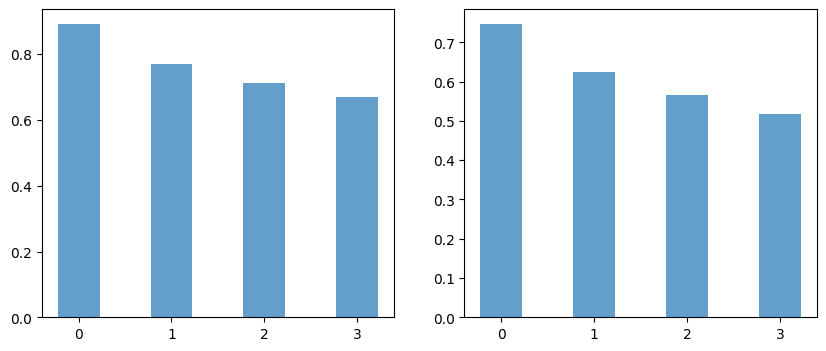

In [7]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
auc_list = [0.892,0.769,0.711,0.669]#CatB,IForest,yolo_day,my_sgg
csi_list = [0.747,0.625,0.566,0.517]
methods_list = np.arange(4)
bar_width = 0.45
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.bar(methods_list,auc_list,bar_width,  alpha=0.7)
plt.xticks(np.arange(0, 4, step=1))
plt.subplot(122)
plt.bar(methods_list,csi_list,bar_width,  alpha=0.7)
plt.xticks(np.arange(0, 4, step=1))
# plt.savefig(f'./paper_related/ocean_generalize.png')
# plt.savefig(f'./paper_related/ocean_generalize.pdf')

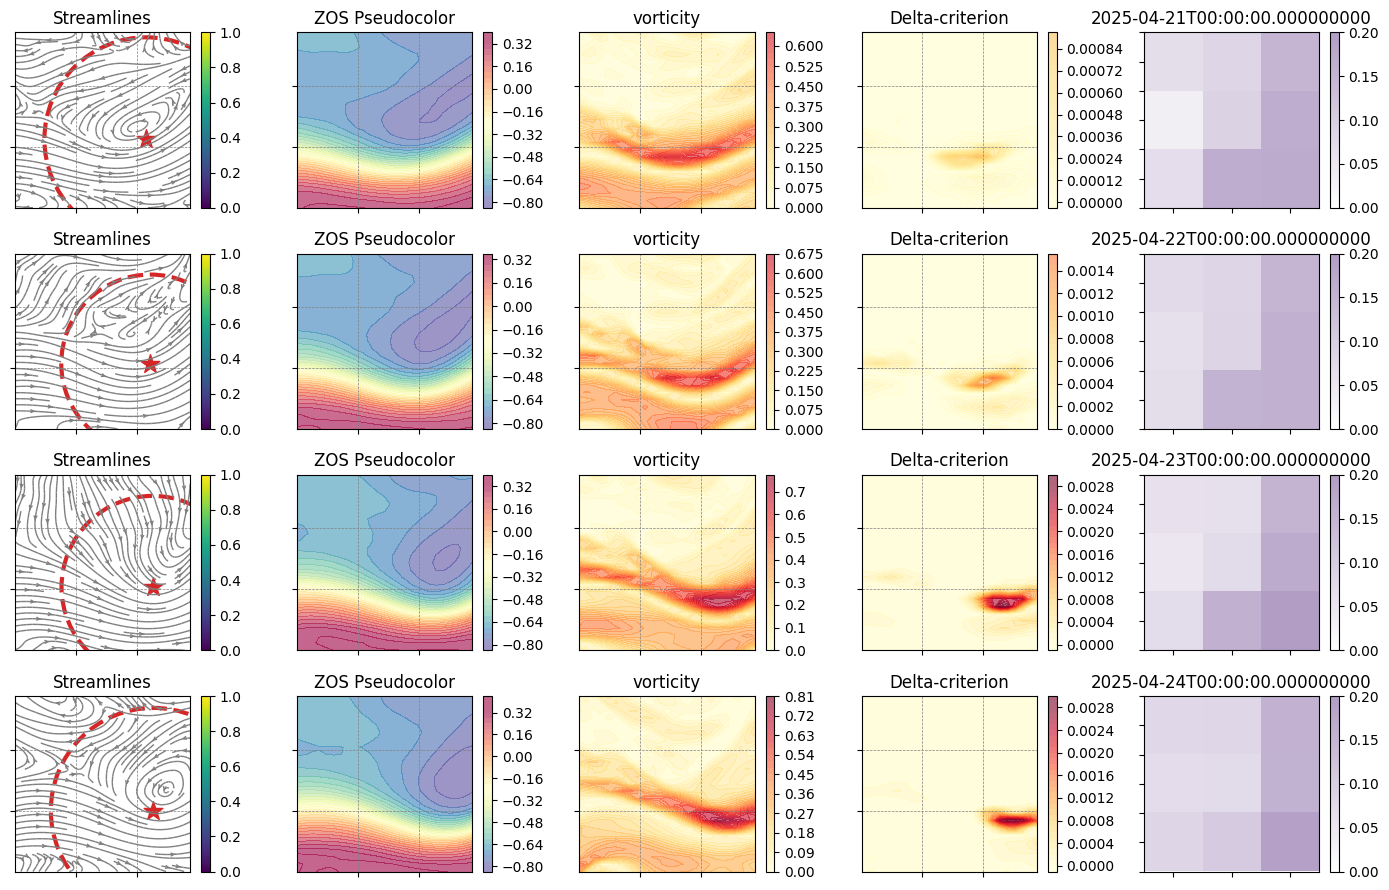

In [10]:

from matplotlib.colors import LinearSegmentedColormap
purple_cmap = LinearSegmentedColormap.from_list('white_to_purple', ['#FFFFFF', "#B29DC5"], N=256)
def visualize_attention_with_stream_save(model, axes, test_sample, u_data, v_data, 
                                   has_eddy=False, eddy_info=None,id=1,times = None,lon_min = -71.0,lat_max = 39.0):
    """
    可视化注意力图和伪彩色流线图
    
    参数:
    ----------
    model: 训练好的模型
    test_sample: 测试样本 [3, 25, 25]
    u_data, v_data: 流场数据 [25, 25]
    background: 背景颜色 'black' 或 'white'
    has_eddy: 是否有涡旋标注
    eddy_info: 涡旋信息字典，包含中心位置、半径等
    """
    model.eval()
    
    # 自动获取模型所在的设备
    device = next(model.parameters()).device
    
    # 准备输入
    if isinstance(test_sample, np.ndarray):
        test_sample_tensor = torch.FloatTensor(test_sample).unsqueeze(0).to(device)
    elif isinstance(test_sample, torch.Tensor):
        test_sample_tensor = test_sample.unsqueeze(0).to(device)
    
    # 前向传播获取注意力图
    with torch.no_grad():
        output, attention_map,_ = model(test_sample_tensor)
        probabilities = F.softmax(output, dim=1)
        pred_class = output.argmax(dim=1).item()
        pred_prob = probabilities[0, pred_class].item()
    
    # 获取注意力图和数据
    attention_map_np = attention_map.squeeze().cpu().numpy()  # [4, 4]
    sample_data = test_sample_tensor.squeeze().cpu().numpy()  # [3, 25, 25]
    # 将4×4的注意力图上采样到25×25以便可视化
    attention_map_resized = cv2.resize(attention_map_np, (25, 25), interpolation=cv2.INTER_CUBIC)
    
    # 获取zos数据并创建伪彩色图
    zos_data = sample_data[2]  # [25, 25]
    x = np.arange(25)
    y = np.arange(25)
    X, Y = np.meshgrid(x, y)
    
    # 创建图形
    
    ticks = [25/3,50/3]
    # 绘制流线
    axes[0].streamplot(X, Y, u_data, v_data, 
                               color='C7',
                               linewidth=1,
                               arrowsize=0.5,
                               density=1,
                               arrowstyle='->')
    speed = np.hypot(u_data, v_data)
    import matplotlib.colors as mcolors
    norm_speed = mcolors.Normalize(vmin=0, vmax=2)
    if has_eddy and eddy_info is not None:
        _,_,_,_,c_lat, c_lon, r_pixel,_ = eddy_info
        
        deg_per_pixel = 2.0 / 25
        cx = (c_lon - lon_min) / deg_per_pixel
        cy = (lat_max - c_lat) / deg_per_pixel  # y轴从上往下
        r = r_pixel #r是在25*25的网格上定义的     
        circle = Circle(
                    xy=(cx,cy),      # 圆心坐标 (x, y)
                    radius=r,        # 半径
                    edgecolor='C3',    # 边框颜色
                    facecolor='none', # 填充颜色
                    linewidth=3,        # 边框宽度
                    linestyle='--',     # 边框样式
                )
        axes[0].add_patch(circle)
    im1 = axes[0].scatter(cx,cy,marker='*',s=200,c='C3')
    axes[0].set_title(f'Streamlines')
    axes[0].set_xticks(ticks)
    axes[0].set_yticks(ticks)
    axes[0].set_xticklabels(())
    axes[0].set_yticklabels(())
    axes[0].set_xlim((0,24))
    axes[0].set_ylim((0,24))
    axes[0].grid(True,  color='gray', linewidth=0.5,linestyle='--')

    im2 = axes[1].contourf(zos_data, levels=30, alpha=0.6, cmap='Spectral_r',vmax = 0.32,vmin=-0.8)
    axes[1].set_title('ZOS Pseudocolor')
    axes[1].set_xticks(ticks)
    axes[1].set_yticks(ticks)
    axes[1].set_xticklabels(())
    axes[1].set_yticklabels(())
    axes[1].grid(True,  color='gray', linewidth=0.5,linestyle='--')

    dv_dx = np.gradient(v_data, axis=1) 
    dv_dy = np.gradient(v_data, axis=0) 
    du_dy = np.gradient(u_data, axis=0) 
    du_dx = np.gradient(u_data, axis=1)  # ∂u/∂y
    vorticity = (dv_dx - du_dy)
    S_xx = du_dx                    # S[0,0]
    S_yy = dv_dy                    # S[1,1]
    S_xy = 0.5 * (du_dy + dv_dx)    # S[0,1] = S[1,0]
    Omega_12 = 0.5 * vorticity     # Ω[0,1]
    Omega_21 = -0.5 * vorticity    # Ω[1,0]
    # 计算Frobenius范数
    # ‖Ω‖² = Ω_12² + Ω_21² = 2*(ω/2)² = ω²/2
    Omega_norm_sq = Omega_12**2 + Omega_21**2
    # ‖S‖² = S_xx² + 2*S_xy² + S_yy²
    S_norm_sq = S_xx**2 + 2 * S_xy**2 + S_yy**2
    # Q值
    Q = 0.5 * (Omega_norm_sq - S_norm_sq)
    det_gradV = du_dx * dv_dy - du_dy * dv_dx
    Delta = (Q/3)**3 + (det_gradV/2)**2
    vort_magnitude = np.abs(vorticity)#
    im3 = axes[2].contourf(vort_magnitude, levels=30, alpha=0.6, cmap='YlOrRd',vmax = 0.81,vmin=0)
    axes[2].set_title('vorticity')
    axes[2].set_xticks(ticks)
    axes[2].set_yticks(ticks)
    axes[2].set_xticklabels(())
    axes[2].set_yticklabels(())
    axes[2].grid(True,  color='gray', linewidth=0.5,linestyle='--')
    plt.colorbar(im3, ax=axes[2])

    im4 = axes[3].contourf(Delta, levels=30, alpha=0.6, cmap='YlOrRd',vmax = 0.0028,vmin=0)
    axes[3].set_title('Delta-criterion')
    axes[3].set_xticks(ticks)
    axes[3].set_yticks(ticks)
    axes[3].set_xticklabels(())
    axes[3].set_yticklabels(())
    axes[3].grid(True,  color='gray', linewidth=0.5,linestyle='--')
    
    # 图2: 自注意力图
    im5 = axes[4].imshow(attention_map_np, cmap=purple_cmap, origin='lower', aspect='auto',vmax = 0.2,vmin=0)# 
    axes[4].set_title('Learnt attention map')
    axes[4].set_xticklabels(())
    axes[4].set_yticklabels(())
    axes[4].set_title(times[id])

    plt.colorbar(im1, ax=axes[0])
    plt.colorbar(im2, ax=axes[1])
    plt.colorbar(im4, ax=axes[3])
    plt.colorbar(im5, ax=axes[4])
    plt.tight_layout()
    

    return attention_map_np, attention_map_resized, pred_class, pred_prob
transfer_idx = 0
transfer_regions = ['mexico','agulhas','brazil','kuroshio']
transfer_region = transfer_regions[transfer_idx]
set_all_seeds()
# model = train_with_mexico()
# torch.save(model.state_dict(), 'trained_mexico.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=0.2).to(device)
model.load_state_dict(torch.load(f'trained_{transfer_region}.pth'))#trained_agulhas(直接训练， batch_size=32，lr=0.0001)#trained_brazil(transfer,trained_mexico训练LR=0.0001，batch_size=32)#trained_kuroshio(直接训练，batch_size=32，lr=0.0001)
lon_mins = [-71,18,-52,142]
lat_maxs = [39,-35,-38,37]
train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test = dataset_generate(transfer_region)
ocean_eddy_2025_path = f'ocean_eddy_test_2025_{transfer_region}'
ocean_eddy_2025 = scio.loadmat(f'./ocean_eddy/{ocean_eddy_2025_path}.mat')
fig, axes = plt.subplots(4, 5, figsize=(14, 9))
i_row = 0
for i in [120,144,168,192]:#range(int(len(test_data)/2-1)):#
    # print(f'selected: {i}')
    eddy_info = full_annotations_test[i]#ann_test_new[i]
    attention_map, attention_resized, pred_class, pred_prob = visualize_attention_with_stream_save(
                model=model,axes = axes[i_row],
                test_sample=test_data[i,...],
                u_data=test_data[i,0,...],
                v_data=test_data[i,1,...],
                has_eddy=(test_labels[i] == 1),  # 是否有涡旋
                eddy_info=eddy_info, id = i,times = ocean_eddy_2025['labeled_time_str'],lon_min=lon_mins[transfer_idx],lat_max=lat_maxs[transfer_idx])
    
    i_row = i_row+1
    # attention_map, guidance_map, physics_guidance, annotation_guidance, max_pos = attention_obtain(model=model,test_sample=test_data[i,...],eddy_info=eddy_info)
    # print(guidance_map)
    # print(eddy_info)
plt.show()
# plt.savefig(f'E:\work_in_2025\study\hazard_assess_multi_11_vr\paper_related/test_mexico1.svg',dpi=600,facecolor='white')
# # plt.savefig(f'E:\work_in_2025\study\hazard_assess_multi_11_vr\paper_related/test_mexico.png')
# plt.close()

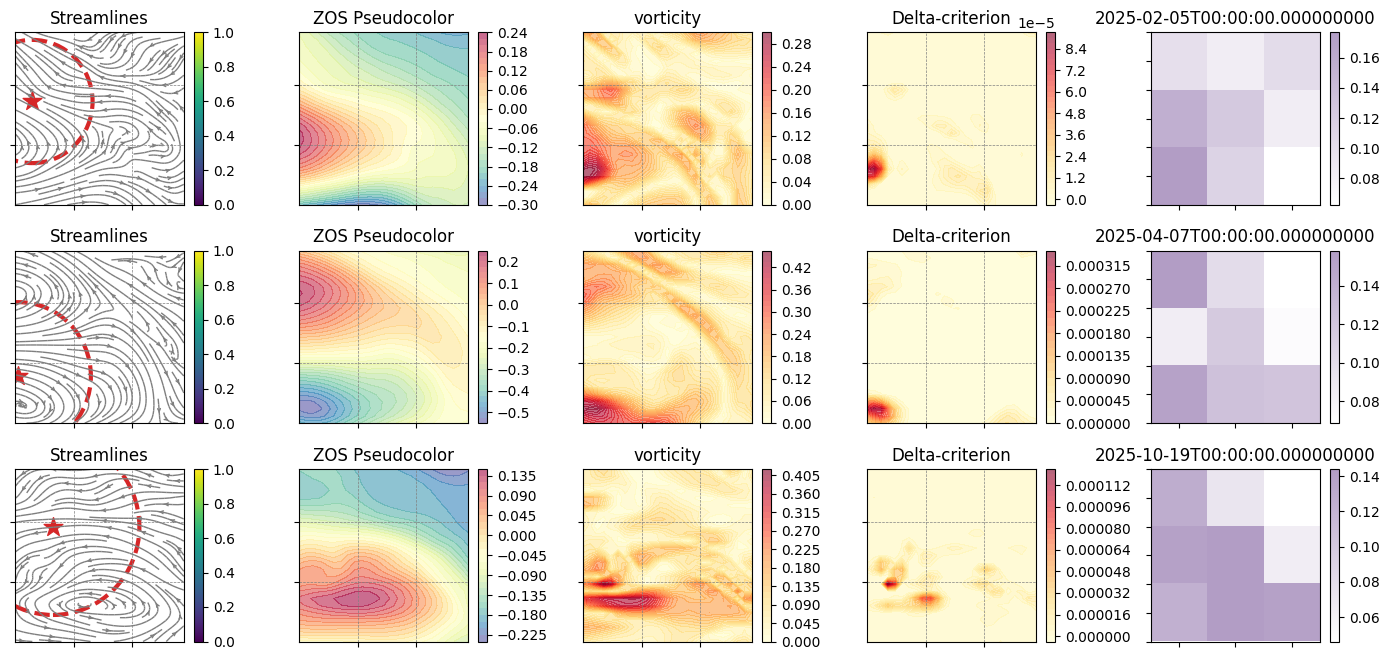

In [4]:
from matplotlib.colors import LinearSegmentedColormap
purple_cmap = LinearSegmentedColormap.from_list('white_to_purple', ['#FFFFFF', "#B29DC5"], N=256)
def visualize_attention_with_stream_save(model, axes, test_sample, u_data, v_data, 
                                   has_eddy=False, eddy_info=None,id=1,times = None,lon_min = -71.0,lat_max = 39.0):
    """
    可视化注意力图和伪彩色流线图
    
    参数:
    ----------
    model: 训练好的模型
    test_sample: 测试样本 [3, 25, 25]
    u_data, v_data: 流场数据 [25, 25]
    background: 背景颜色 'black' 或 'white'
    has_eddy: 是否有涡旋标注
    eddy_info: 涡旋信息字典，包含中心位置、半径等
    """
    model.eval()
    
    # 自动获取模型所在的设备
    device = next(model.parameters()).device
    
    # 准备输入
    if isinstance(test_sample, np.ndarray):
        test_sample_tensor = torch.FloatTensor(test_sample).unsqueeze(0).to(device)
    elif isinstance(test_sample, torch.Tensor):
        test_sample_tensor = test_sample.unsqueeze(0).to(device)
    
    # 前向传播获取注意力图
    with torch.no_grad():
        output, attention_map,_ = model(test_sample_tensor)
        probabilities = F.softmax(output, dim=1)
        pred_class = output.argmax(dim=1).item()
        pred_prob = probabilities[0, pred_class].item()
    
    # 获取注意力图和数据
    attention_map_np = attention_map.squeeze().cpu().numpy()  # [4, 4]
    sample_data = test_sample_tensor.squeeze().cpu().numpy()  # [3, 25, 25]
    # 将4×4的注意力图上采样到25×25以便可视化
    attention_map_resized = cv2.resize(attention_map_np, (25, 25), interpolation=cv2.INTER_CUBIC)
    
    # 获取zos数据并创建伪彩色图
    zos_data = sample_data[2]  # [25, 25]
    x = np.arange(25)
    y = np.arange(25)
    X, Y = np.meshgrid(x, y)
    
    # 创建图形
    
    ticks = [25/3,50/3]
    # 绘制流线
    axes[0].streamplot(X, Y, u_data, v_data, 
                               color='C7',
                               linewidth=1,
                               arrowsize=0.5,
                               density=1,
                               arrowstyle='->')
    speed = np.hypot(u_data, v_data)
    import matplotlib.colors as mcolors
    norm_speed = mcolors.Normalize(vmin=0, vmax=2)
    if has_eddy and eddy_info is not None:
        _,_,_,_,c_lat, c_lon, r_pixel,_ = eddy_info
        
        deg_per_pixel = 2.0 / 25
        cx = (c_lon - lon_min) / deg_per_pixel
        cy = (lat_max - c_lat) / deg_per_pixel  # y轴从上往下
        r = r_pixel #r是在25*25的网格上定义的     
        circle = Circle(
                    xy=(cx,cy),      # 圆心坐标 (x, y)
                    radius=r,        # 半径
                    edgecolor='C3',    # 边框颜色
                    facecolor='none', # 填充颜色
                    linewidth=3,        # 边框宽度
                    linestyle='--',     # 边框样式
                )
        axes[0].add_patch(circle)
    im1 = axes[0].scatter(cx,cy,marker='*',s=200,c='C3')
    axes[0].set_title(f'Streamlines')
    axes[0].set_xticks(ticks)
    axes[0].set_yticks(ticks)
    axes[0].set_xticklabels(())
    axes[0].set_yticklabels(())
    axes[0].set_xlim((0,24))
    axes[0].set_ylim((0,24))
    axes[0].grid(True,  color='gray', linewidth=0.5,linestyle='--')

    im2 = axes[1].contourf(zos_data, levels=30, alpha=0.6, cmap='Spectral_r')
    axes[1].set_title('ZOS Pseudocolor')
    axes[1].set_xticks(ticks)
    axes[1].set_yticks(ticks)
    axes[1].set_xticklabels(())
    axes[1].set_yticklabels(())
    axes[1].grid(True,  color='gray', linewidth=0.5,linestyle='--')

    dv_dx = np.gradient(v_data, axis=1) 
    dv_dy = np.gradient(v_data, axis=0) 
    du_dy = np.gradient(u_data, axis=0) 
    du_dx = np.gradient(u_data, axis=1)  # ∂u/∂y
    vorticity = (dv_dx - du_dy)
    S_xx = du_dx                    # S[0,0]
    S_yy = dv_dy                    # S[1,1]
    S_xy = 0.5 * (du_dy + dv_dx)    # S[0,1] = S[1,0]
    Omega_12 = 0.5 * vorticity     # Ω[0,1]
    Omega_21 = -0.5 * vorticity    # Ω[1,0]
    # 计算Frobenius范数
    # ‖Ω‖² = Ω_12² + Ω_21² = 2*(ω/2)² = ω²/2
    Omega_norm_sq = Omega_12**2 + Omega_21**2
    # ‖S‖² = S_xx² + 2*S_xy² + S_yy²
    S_norm_sq = S_xx**2 + 2 * S_xy**2 + S_yy**2
    # Q值
    Q = 0.5 * (Omega_norm_sq - S_norm_sq)
    det_gradV = du_dx * dv_dy - du_dy * dv_dx
    Delta = (Q/3)**3 + (det_gradV/2)**2
    vort_magnitude = np.abs(vorticity)#
    im3 = axes[2].contourf(vort_magnitude, levels=30, alpha=0.6, cmap='YlOrRd')
    axes[2].set_title('vorticity')
    axes[2].set_xticks(ticks)
    axes[2].set_yticks(ticks)
    axes[2].set_xticklabels(())
    axes[2].set_yticklabels(())
    axes[2].grid(True,  color='gray', linewidth=0.5,linestyle='--')
    plt.colorbar(im3, ax=axes[2])

    im4 = axes[3].contourf(Delta, levels=30, alpha=0.6, cmap='YlOrRd')
    axes[3].set_title('Delta-criterion')
    axes[3].set_xticks(ticks)
    axes[3].set_yticks(ticks)
    axes[3].set_xticklabels(())
    axes[3].set_yticklabels(())
    axes[3].grid(True,  color='gray', linewidth=0.5,linestyle='--')
    
    # 图2: 自注意力图
    im5 = axes[4].imshow(attention_map_np, cmap=purple_cmap, origin='lower', aspect='auto',)# 
    axes[4].set_title('Learnt attention map')
    axes[4].set_xticklabels(())
    axes[4].set_yticklabels(())
    axes[4].set_title(times[id])

    plt.colorbar(im1, ax=axes[0])
    plt.colorbar(im2, ax=axes[1])
    plt.colorbar(im4, ax=axes[3])
    plt.colorbar(im5, ax=axes[4])
    plt.tight_layout()
    

    return attention_map_np, attention_map_resized, pred_class, pred_prob
transfer_idx = 1
transfer_regions = ['mexico','agulhas','brazil','kuroshio']
transfer_region = transfer_regions[transfer_idx]
set_all_seeds()
# model = train_with_mexico()
# torch.save(model.state_dict(), 'trained_mexico.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=0.2).to(device)
model.load_state_dict(torch.load(f'trained_{transfer_region}.pth'))#trained_agulhas(直接训练， batch_size=32，lr=0.0001)#trained_brazil(transfer,trained_mexico训练LR=0.0001，batch_size=32)#trained_kuroshio(直接训练，batch_size=32，lr=0.0001)
lon_mins = [-71,18,-52,142]
lat_maxs = [39,-35,-38,37]
train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test = dataset_generate(transfer_region)
ocean_eddy_2025_path = f'ocean_eddy_test_2025_{transfer_region}'
ocean_eddy_2025 = scio.loadmat(f'./ocean_eddy/{ocean_eddy_2025_path}.mat')
fig, axes = plt.subplots(3, 5, figsize=(14, 6.7))
i_row = 0
for i in [24,336,672]:#range(int(len(test_data)/2-1)):#
    # print(f'selected: {i}')
    eddy_info = full_annotations_test[i]#ann_test_new[i]
    attention_map, attention_resized, pred_class, pred_prob = visualize_attention_with_stream_save(
                model=model,axes = axes[i_row],
                test_sample=test_data[i,...],
                u_data=test_data[i,0,...],
                v_data=test_data[i,1,...],
                has_eddy=(test_labels[i] == 1),  # 是否有涡旋
                eddy_info=eddy_info, id = i,times = ocean_eddy_2025['labeled_time_str'],lon_min=lon_mins[transfer_idx],lat_max=lat_maxs[transfer_idx])
    
    i_row = i_row+1
    # attention_map, guidance_map, physics_guidance, annotation_guidance, max_pos = attention_obtain(model=model,test_sample=test_data[i,...],eddy_info=eddy_info)
    # print(guidance_map)
    # print(eddy_info)
plt.show()
# plt.savefig(f'E:\work_in_2025\study\hazard_assess_multi_11_vr\paper_related/test_mexico1.svg',dpi=600,facecolor='white')
# # plt.savefig(f'E:\work_in_2025\study\hazard_assess_multi_11_vr\paper_related/test_mexico.png')
# plt.close()

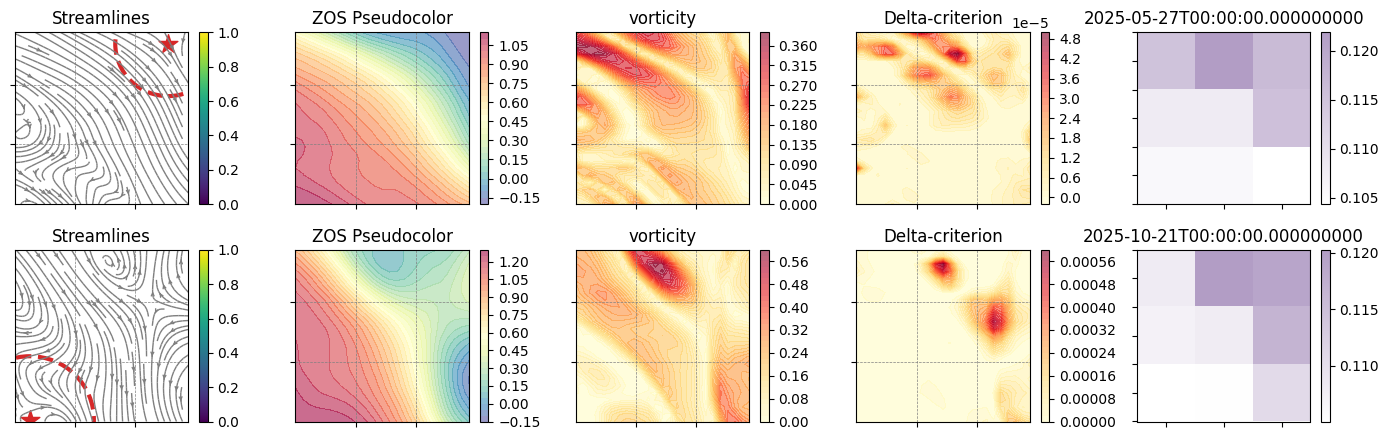

In [5]:
transfer_idx = 3
transfer_regions = ['mexico','agulhas','brazil','kuroshio']
transfer_region = transfer_regions[transfer_idx]
set_all_seeds()
# model = train_with_mexico()
# torch.save(model.state_dict(), 'trained_mexico.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=0.2).to(device)
model.load_state_dict(torch.load(f'trained_{transfer_region}.pth'))#trained_agulhas(直接训练， batch_size=32，lr=0.0001)#trained_brazil(transfer,trained_mexico训练LR=0.0001，batch_size=32)#trained_kuroshio(直接训练，batch_size=32，lr=0.0001)
lon_mins = [-71,18,-52,142]
lat_maxs = [39,-35,-38,37]
train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test = dataset_generate(transfer_region)
ocean_eddy_2025_path = f'ocean_eddy_test_2025_{transfer_region}'
ocean_eddy_2025 = scio.loadmat(f'./ocean_eddy/{ocean_eddy_2025_path}.mat')
fig, axes = plt.subplots(2, 5, figsize=(14, 4.5))
i_row = 0
for i in [480,672]:#range(int(len(test_data)/2-1)):#
    # print(f'selected: {i}')
    eddy_info = full_annotations_test[i]#ann_test_new[i]
    attention_map, attention_resized, pred_class, pred_prob = visualize_attention_with_stream_save(
                model=model,axes = axes[i_row],
                test_sample=test_data[i,...],
                u_data=test_data[i,0,...],
                v_data=test_data[i,1,...],
                has_eddy=(test_labels[i] == 1),  # 是否有涡旋
                eddy_info=eddy_info, id = i,times = ocean_eddy_2025['labeled_time_str'],lon_min=lon_mins[transfer_idx],lat_max=lat_maxs[transfer_idx])
    
    i_row = i_row+1
    # attention_map, guidance_map, physics_guidance, annotation_guidance, max_pos = attention_obtain(model=model,test_sample=test_data[i,...],eddy_info=eddy_info)
    # print(guidance_map)
    # print(eddy_info)
plt.savefig(f'E:\work_in_2025\study\hazard_assess_multi_11_vr\paper_related/test_kurshio.svg',dpi=600,facecolor='white')
plt.show()

[0.44439859688282013, 0.8054741621017456, 0.9365446269512177]
Spearman rho = 1.000
Spearman p = 0.000
NRMSE = 0.330


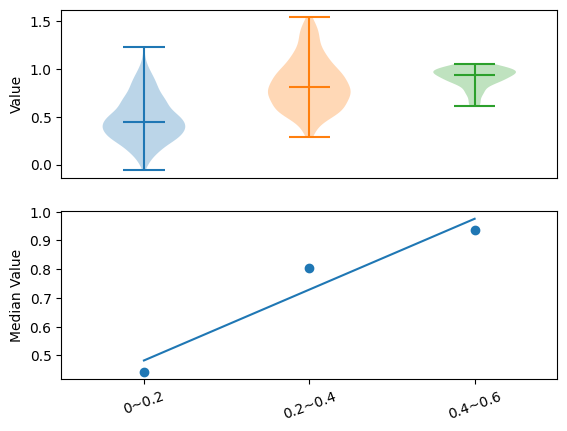

In [21]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
def normalized_nrmse(y_true, y_pred):
    # 分别归一化到[0,1]
    y_true_norm = (y_true - np.min(y_true)) / (np.max(y_true) - np.min(y_true))
    y_pred_norm = (y_pred - np.min(y_pred)) / (np.max(y_pred) - np.min(y_pred))
    
    # 然后计算NRMSE
    mse = np.mean((y_pred_norm - y_true_norm) ** 2)
    var = np.var(y_true_norm)
    return np.sqrt(mse / var) if var != 0 else float('inf')

def compute_intensity(data):
    data = np.array(data)
    x = np.array([0,0.2,0.4])
    spearman_rho, spearman_p = stats.spearmanr(x, data)
    print(f"Spearman rho = {spearman_rho:.3f}")
    print(f"Spearman p = {spearman_p:.3f}")
    print(f'NRMSE = {normalized_nrmse(x, data):.3f}')

transfer_idx = 0
transfer_regions = ['mexico','agulhas','brazil','kuroshio']
transfer_region = transfer_regions[transfer_idx]
set_all_seeds()
# model = train_with_mexico()
# torch.save(model.state_dict(), 'trained_mexico.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=0.2).to(device)
model.load_state_dict(torch.load(f'trained_{transfer_region}.pth'))#trained_agulhas(直接训练， batch_size=32，lr=0.0001)#trained_brazil(transfer,trained_mexico训练LR=0.0001，batch_size=32)#trained_kuroshio(直接训练，batch_size=32，lr=0.0001)
model.eval()
train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test = dataset_generate(transfer_region)
eddy_info = full_annotations_test#[0:2,...]

# 准备输入
test_sample = test_data#[0:2,...]
if isinstance(test_sample, np.ndarray):
    test_sample_tensor = torch.FloatTensor(test_sample).to(device)
elif isinstance(test_sample, torch.Tensor):
    test_sample_tensor = test_sample.to(device)
output, attention_map, decoded_feature = model(test_sample_tensor)
eddy_prob = output[:,1]#torch.exp(output[:,1])/torch.exp(output).sum(axis=1)#((output[:,1]/(output[:,0]))*output[:,0]/torch.abs(output[:,0]))
def fit(x,y):
    coefficients = np.polyfit(x, y, 1)# 进行线性拟合（1 表示一次多项式，即直线）
    poly = np.poly1d(coefficients)  # 生成多项式对象
    return poly(x)
amplitude_intervals = [0,0.2,0.4,0.6]
eddy_feature_median = []
eddy_mag_names = []
eddy_prob_np = eddy_prob.cpu().detach().numpy()
plt.subplot(211)
for i in range(1,len(amplitude_intervals)):
    index_mag = np.where((full_annotations_test[:,-1]>= amplitude_intervals[i-1])
                            &(full_annotations_test[:,-1]< amplitude_intervals[i]))
    if (index_mag[0].shape[0]>2):
        label_for_legend = f'{amplitude_intervals[i-1]}~{amplitude_intervals[i]}'
        eddy_feature_median.append((np.percentile(eddy_prob_np[index_mag[0]],50)))
        eddy_mag_names.append(label_for_legend)
        plt.violinplot(eddy_prob_np[index_mag[0]], [len(eddy_mag_names) - 1], showmedians=True)  #
plt.xticks(())
plt.xlim((-0.5, len(eddy_mag_names) - 0.5))
plt.ylabel('Value')
plt.subplot(212)
plt.scatter(np.arange(len(eddy_mag_names)), eddy_feature_median,  marker='o')
plt.plot(np.arange(len(eddy_mag_names)), fit(np.arange(len(eddy_mag_names)),eddy_feature_median), '-')
plt.xticks(np.arange(len(eddy_mag_names)), (eddy_mag_names), rotation=20)
plt.ylabel('Median Value')
plt.xlim((-0.5, len(eddy_mag_names) - 0.5))
print(eddy_feature_median)
compute_intensity(eddy_feature_median)

[0.10454461351037025, 0.34625084698200226, 0.7265746891498566]
Spearman rho = 1.000
Spearman p = 0.000
NRMSE = 0.158


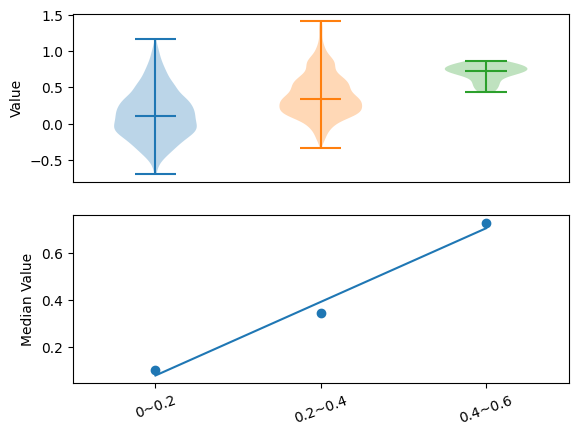

In [22]:
transfer_idx = 1
transfer_regions = ['mexico','agulhas','brazil','kuroshio']
transfer_region = transfer_regions[transfer_idx]
set_all_seeds()
# model = train_with_mexico()
# torch.save(model.state_dict(), 'trained_mexico.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=0.2).to(device)
model.load_state_dict(torch.load(f'trained_{transfer_region}.pth'))#trained_agulhas(直接训练， batch_size=32，lr=0.0001)#trained_brazil(transfer,trained_mexico训练LR=0.0001，batch_size=32)#trained_kuroshio(直接训练，batch_size=32，lr=0.0001)
model.eval()
train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test = dataset_generate(transfer_region)
eddy_info = full_annotations_test#[0:2,...]

# 准备输入
test_sample = test_data#[0:2,...]
if isinstance(test_sample, np.ndarray):
    test_sample_tensor = torch.FloatTensor(test_sample).to(device)
elif isinstance(test_sample, torch.Tensor):
    test_sample_tensor = test_sample.to(device)
output, attention_map, decoded_feature = model(test_sample_tensor)
eddy_prob = output[:,1]#torch.exp(output[:,1])/torch.exp(output).sum(axis=1)#((output[:,1]/(output[:,0]))*output[:,0]/torch.abs(output[:,0]))
def fit(x,y):
    coefficients = np.polyfit(x, y, 1)# 进行线性拟合（1 表示一次多项式，即直线）
    poly = np.poly1d(coefficients)  # 生成多项式对象
    return poly(x)
amplitude_intervals = [0,0.2,0.4,0.6]
eddy_feature_median = []
eddy_mag_names = []
eddy_prob_np = eddy_prob.cpu().detach().numpy()
plt.subplot(211)
for i in range(1,len(amplitude_intervals)):
    index_mag = np.where((full_annotations_test[:,-1]>= amplitude_intervals[i-1])
                            &(full_annotations_test[:,-1]< amplitude_intervals[i]))
    if (index_mag[0].shape[0]>2):
        label_for_legend = f'{amplitude_intervals[i-1]}~{amplitude_intervals[i]}'
        eddy_feature_median.append((np.percentile(eddy_prob_np[index_mag[0]],50)))
        eddy_mag_names.append(label_for_legend)
        plt.violinplot(eddy_prob_np[index_mag[0]], [len(eddy_mag_names) - 1], showmedians=True)  #
plt.xticks(())
plt.xlim((-0.5, len(eddy_mag_names) - 0.5))
plt.ylabel('Value')
plt.subplot(212)
plt.scatter(np.arange(len(eddy_mag_names)), eddy_feature_median,  marker='o')
plt.plot(np.arange(len(eddy_mag_names)), fit(np.arange(len(eddy_mag_names)),eddy_feature_median), '-')
plt.xticks(np.arange(len(eddy_mag_names)), (eddy_mag_names), rotation=20)
plt.ylabel('Median Value')
plt.xlim((-0.5, len(eddy_mag_names) - 0.5))
print(eddy_feature_median)
compute_intensity(eddy_feature_median)

[-0.07920196652412415, 0.05765560269355774, 0.3286691904067993]
Spearman rho = 1.000
Spearman p = 0.000
NRMSE = 0.233


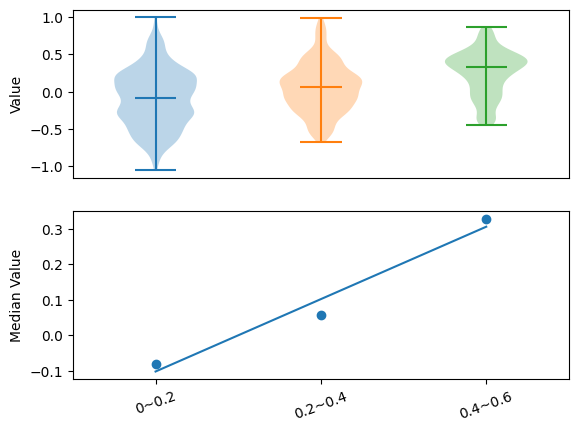

In [23]:
transfer_idx = 2
transfer_regions = ['mexico','agulhas','brazil','kuroshio']
transfer_region = transfer_regions[transfer_idx]
set_all_seeds()
# model = train_with_mexico()
# torch.save(model.state_dict(), 'trained_mexico.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=0.2).to(device)
model.load_state_dict(torch.load(f'trained_{transfer_region}.pth'))#trained_agulhas(直接训练， batch_size=32，lr=0.0001)#trained_brazil(transfer,trained_mexico训练LR=0.0001，batch_size=32)#trained_kuroshio(直接训练，batch_size=32，lr=0.0001)
model.eval()
train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test = dataset_generate(transfer_region)
eddy_info = full_annotations_test#[0:2,...]

# 准备输入
test_sample = test_data#[0:2,...]
if isinstance(test_sample, np.ndarray):
    test_sample_tensor = torch.FloatTensor(test_sample).to(device)
elif isinstance(test_sample, torch.Tensor):
    test_sample_tensor = test_sample.to(device)
output, attention_map, decoded_feature = model(test_sample_tensor)
eddy_prob = output[:,1]#torch.exp(output[:,1])/torch.exp(output).sum(axis=1)#((output[:,1]/(output[:,0]))*output[:,0]/torch.abs(output[:,0]))
def fit(x,y):
    coefficients = np.polyfit(x, y, 1)# 进行线性拟合（1 表示一次多项式，即直线）
    poly = np.poly1d(coefficients)  # 生成多项式对象
    return poly(x)
amplitude_intervals = [0,0.2,0.4,0.6]
eddy_feature_median = []
eddy_mag_names = []
eddy_prob_np = eddy_prob.cpu().detach().numpy()
plt.subplot(211)
for i in range(1,len(amplitude_intervals)):
    index_mag = np.where((full_annotations_test[:,-1]>= amplitude_intervals[i-1])
                            &(full_annotations_test[:,-1]< amplitude_intervals[i]))
    if (index_mag[0].shape[0]>2):
        label_for_legend = f'{amplitude_intervals[i-1]}~{amplitude_intervals[i]}'
        eddy_feature_median.append((np.percentile(eddy_prob_np[index_mag[0]],50)))
        eddy_mag_names.append(label_for_legend)
        plt.violinplot(eddy_prob_np[index_mag[0]], [len(eddy_mag_names) - 1], showmedians=True)  #
plt.xticks(())
plt.xlim((-0.5, len(eddy_mag_names) - 0.5))
plt.ylabel('Value')
plt.subplot(212)
plt.scatter(np.arange(len(eddy_mag_names)), eddy_feature_median,  marker='o')
plt.plot(np.arange(len(eddy_mag_names)), fit(np.arange(len(eddy_mag_names)),eddy_feature_median), '-')
plt.xticks(np.arange(len(eddy_mag_names)), (eddy_mag_names), rotation=20)
plt.ylabel('Median Value')
plt.xlim((-0.5, len(eddy_mag_names) - 0.5))
print(eddy_feature_median)
compute_intensity(eddy_feature_median)

[0.1294335126876831, 0.4637036919593811, 0.3177240937948227]
Spearman rho = 0.500
Spearman p = 0.667
NRMSE = 0.939


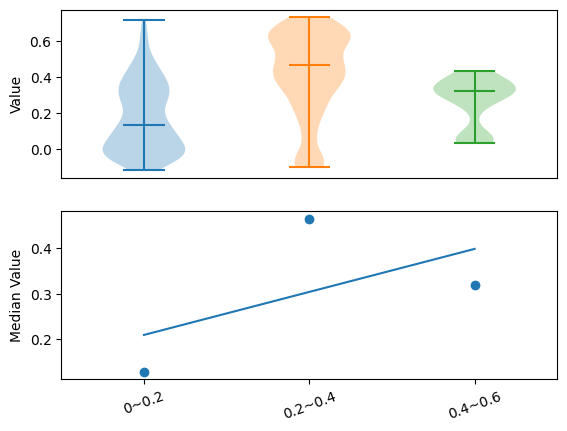

In [24]:
transfer_idx = 3
transfer_regions = ['mexico','agulhas','brazil','kuroshio']
transfer_region = transfer_regions[transfer_idx]
set_all_seeds()
# model = train_with_mexico()
# torch.save(model.state_dict(), 'trained_mexico.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsInformedAttentionNet(input_channels=3,dropout_rate=0.2).to(device)
model.load_state_dict(torch.load(f'trained_{transfer_region}.pth'))#trained_agulhas(直接训练， batch_size=32，lr=0.0001)#trained_brazil(transfer,trained_mexico训练LR=0.0001，batch_size=32)#trained_kuroshio(直接训练，batch_size=32，lr=0.0001)
model.eval()
train_data,train_labels,test_data,test_labels,full_annotations_train,full_annotations_test = dataset_generate(transfer_region)
eddy_info = full_annotations_test#[0:2,...]

# 准备输入
test_sample = test_data#[0:2,...]
if isinstance(test_sample, np.ndarray):
    test_sample_tensor = torch.FloatTensor(test_sample).to(device)
elif isinstance(test_sample, torch.Tensor):
    test_sample_tensor = test_sample.to(device)
output, attention_map, decoded_feature = model(test_sample_tensor)
eddy_prob = output[:,1]#torch.exp(output[:,1])/torch.exp(output).sum(axis=1)#((output[:,1]/(output[:,0]))*output[:,0]/torch.abs(output[:,0]))
def fit(x,y):
    coefficients = np.polyfit(x, y, 1)# 进行线性拟合（1 表示一次多项式，即直线）
    poly = np.poly1d(coefficients)  # 生成多项式对象
    return poly(x)
amplitude_intervals = [0,0.2,0.4,0.6]
eddy_feature_median = []
eddy_mag_names = []
eddy_prob_np = eddy_prob.cpu().detach().numpy()
plt.subplot(211)
for i in range(1,len(amplitude_intervals)):
    index_mag = np.where((full_annotations_test[:,-1]>= amplitude_intervals[i-1])
                            &(full_annotations_test[:,-1]< amplitude_intervals[i]))
    if (index_mag[0].shape[0]>2):
        label_for_legend = f'{amplitude_intervals[i-1]}~{amplitude_intervals[i]}'
        eddy_feature_median.append((np.percentile(eddy_prob_np[index_mag[0]],50)))
        eddy_mag_names.append(label_for_legend)
        plt.violinplot(eddy_prob_np[index_mag[0]], [len(eddy_mag_names) - 1], showmedians=True)  #
plt.xticks(())
plt.xlim((-0.5, len(eddy_mag_names) - 0.5))
plt.ylabel('Value')
plt.subplot(212)
plt.scatter(np.arange(len(eddy_mag_names)), eddy_feature_median,  marker='o')
plt.plot(np.arange(len(eddy_mag_names)), fit(np.arange(len(eddy_mag_names)),eddy_feature_median), '-')
plt.xticks(np.arange(len(eddy_mag_names)), (eddy_mag_names), rotation=20)
plt.ylabel('Median Value')
plt.xlim((-0.5, len(eddy_mag_names) - 0.5))
print(eddy_feature_median)
compute_intensity(eddy_feature_median)

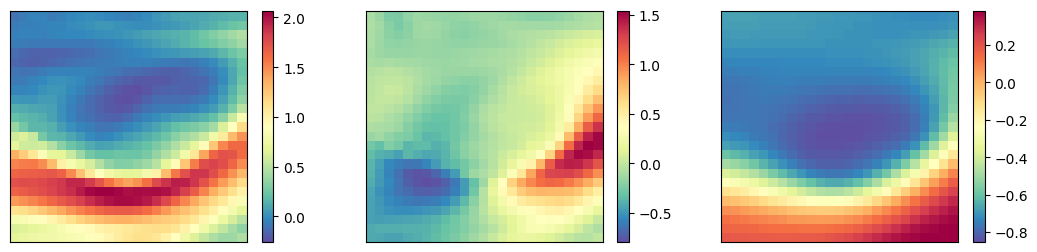

In [1]:
import scipy.io as scio
import matplotlib.pyplot as plt
eddy_dataset = scio.loadmat('eddy_dataset_22_23_24_25.mat')#
labeled_data_2022 = eddy_dataset['labeled_data_2022']
labeled_data_2023 = eddy_dataset['labeled_data_2023']
labeled_data_2024 = eddy_dataset['labeled_data_2024']
labeled_data_2025 = eddy_dataset['labeled_data_2025']
i=0
plt.figure(figsize=(13,3))
plt.subplot(131)
plt.pcolor(labeled_data_2025[i,...,0],cmap='Spectral_r')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.subplot(132)
plt.pcolor(labeled_data_2025[i,...,1],cmap='Spectral_r')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.subplot(133)
plt.pcolor(labeled_data_2025[i,...,2],cmap='Spectral_r')
plt.xticks([])
plt.yticks([])
plt.colorbar()
# plt.savefig(f'E:\work_in_2025\study\hazard_assess_multi_11_vr\paper_related\\eddy_u_v_z.pdf')

In [2]:
import scipy.io as scio
import matplotlib.pyplot as plt
import numpy as np
eddy_dataset = scio.loadmat('eddy_dataset_22_23_24_25.mat')#
calm_data_2023 = eddy_dataset['calm_data_2023']
calm_data_2024 = eddy_dataset['calm_data_2024']
calm_data_2025 = eddy_dataset['calm_data_2025']
labeled_data_2023 = eddy_dataset['labeled_data_2023']
labeled_data_2024 = eddy_dataset['labeled_data_2024']
labeled_data_2025 = eddy_dataset['labeled_data_2025']
labeled_train = np.vstack((labeled_data_2023,labeled_data_2024))#,labeled_data_2023
calm_train = np.vstack((calm_data_2023,calm_data_2024))#,calm_data_2023
labeled_test = labeled_data_2025
calm_test = calm_data_2025
print(f'labeled_train_shape = {labeled_train.shape}')
print(f'calm_train_shape = {calm_train.shape}')
print(f'labeled_test_shape = {labeled_test.shape}')
print(f'calm_test_shape = {calm_test.shape}')

labeled_train_shape = (2784, 25, 25, 3)
calm_train_shape = (2784, 25, 25, 3)
labeled_test_shape = (624, 25, 25, 3)
calm_test_shape = (624, 25, 25, 3)
